In [1]:
import pandas as pd
import warnings
# Ignoring FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
import numpy as np
import os
import time
import pickle
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,f1_score,mean_squared_error,roc_auc_score
from sklearn.model_selection import GridSearchCV,KFold,train_test_split

from itertools import chain
import math

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader,Dataset
from torch.nn.utils.rnn import pad_sequence,pack_padded_sequence,pad_packed_sequence
from torch.optim.lr_scheduler import CosineAnnealingLR, CyclicLR
from torch.optim.swa_utils import AveragedModel
#from pytorch_model_summary import summary

# 1. DEFINE FUNCTIONS FOR LSTM

## Define LSTM

In [2]:
# Define a custom Dataset for handling grouped training data
class Grouped_Train_Dataset(Dataset):
    def __init__(self, X,y,model_complex,columns_to_drop):
        self.X = X
        self.y = y
        self.training_days = training_days
        self.patients=X['USUBJID'].unique()
        self.model_complex=model_complex
        #print('Training data shape',self.X.shape)

    def __len__(self):
        return len(self.X['COMBNUM'].unique())

    def __getitem__(self, idx):
        combnum_dict=dict(zip(np.arange(len(self.X['COMBNUM'].unique())),self.X['COMBNUM'].unique()))
        combnum=combnum_dict[idx]
        X_patient_data=self.X[self.X['COMBNUM']==combnum]
        pat_id=X_patient_data['USUBJID'].unique()
        y_patient_data=self.y[self.y.index.get_level_values('USUBJID').isin(pat_id)]

        if self.model_complex=='day_only':
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID will be dropped later in the script
            X_patient_data=X_patient_data.loc[:,X_patient_data.columns.str.contains('DAY|COMBNUM|STUDY|ARM|USUBJID',regex=True)] 

        if self.model_complex=='regimen_only':       
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID|DAY will be dropped later in the script
            X_patient_data=X_patient_data.loc[:,X_patient_data.columns.str.contains('dr_reg|COMBNUM|STUDY|ARM|USUBJID',regex=True)]      
        
        X_patient_data=X_patient_data.loc[:,~X_patient_data.columns.str.contains('|'.join(columns_to_drop +['COMBNUM']),regex=True)]      

        X_patient_data=torch.tensor(X_patient_data.values, dtype=torch.float32)
        y_patient_data=torch.tensor(y_patient_data.values, dtype=torch.float32)

        #print('X_patient_data',X_patient_data.shape)
        #print('y_patient_data',y_patient_data.shape)

        return X_patient_data, y_patient_data    


    def collate_fn(self, batch):
        inputs, targets= zip(*batch)
        inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0)
        targets = torch.stack(targets)
        seq_lens=torch.tensor([len(seq) for seq in inputs],dtype=torch.float32)
        return inputs_padded, targets, seq_lens

'''
##### =======================================
# Define a custom Dataset for handling grouped test data for the training method training_on_first_x_days
class Grouped_Test_Dataset_first_x_days(Dataset):
    def __init__(self, X,y,training_days,std_training_days,model_complex,dataset_type):
        self.X_all_std=X
        self.y=y
        self.training_days = training_days
        self.std_training_days=std_training_days.flatten()[0]
        self.dataset_type=dataset_type
        
        if dataset_type=='training':
            self.X_test=X[X['DAY']<=self.std_training_days]
            self.y_test=y[y.index.get_level_values('STD_DAY')<=self.std_training_days]

        if dataset_type=='testing':
            self.X_test=X[X['DAY']>self.std_training_days]
            self.y_test=y[y.index.get_level_values('STD_DAY')>self.std_training_days]            
        
        self.X_test=self.X_test.reset_index(drop=True)     

    def __len__(self):
        return len(self.X_test)

    def __getitem__(self, idx):
        patient_id = self.X_test.loc[idx,'USUBJID']
        
        ## Get day of study for which the prediction should be made
        day_to_pred=self.X_test.loc[idx,'DAY']
        
        ## If testing data ,add all prior study days, so they can bus used for prediction 
        #  i.e. Training was made on first 10 days, prediction should be made for day 12 
        #  then used Inputs from day1-day12 and predict y for day 12
        if self.dataset_type=='testing':
            
            days_for_prediction=self.X_all_std.loc[(self.X_all_std['USUBJID']==patient_id)&\
                                                (self.X_all_std['DAY']<=self.std_training_days),'DAY'].tolist() + [day_to_pred]
        
        ## If training, then just take all the days prior to the prediction day
        if self.dataset_type=='training':
            days_for_prediction=self.X_all_std.loc[(self.X_all_std['USUBJID']==patient_id)&\
                                                (self.X_all_std['DAY']<=day_to_pred),'DAY'].tolist()

        X_testing_data=self.X_all_std[(self.X_all_std['USUBJID']==patient_id)&\
                                        (self.X_all_std['DAY'].isin(days_for_prediction))].drop(columns=['USUBJID'])

        # Subset the y data for the specific patient and day 
        y_testing_data=self.y_test[(self.y_test.index.get_level_values('USUBJID')==patient_id) &\
                                   (self.y_test.index.get_level_values('STD_DAY')==day_to_pred)]#.drop(columns=['COMBNUM'])    
                                   
        X_testing_data=torch.tensor(X_testing_data.values, dtype=torch.float32)
        y_testing_data=torch.tensor(y_testing_data.values, dtype=torch.float32)

        return X_testing_data, y_testing_data    

'''
##### =======================================
# Define a custom Dataset for handling grouped test data for the training method training_on__whole_data
class Grouped_Test_Dataset_whole_data(Dataset):
    def __init__(self, X_test,y_test,model_complex,columns_to_drop,dataset_type):
        self.X_test=X_test
        self.y_test=y_test
        self.model_complex=model_complex
        self.training_days = training_days
        #self.std_training_days=std_training_days.flatten()[0]      
        
        self.X_test=self.X_test.reset_index(drop=True)     

    def __len__(self):
        return len(self.X_test['COMBNUM'].unique())

    def __getitem__(self, idx):
        #patient_id=self.X_test.loc[idx,'USUBJID']
        combnum_dict=dict(zip(np.arange(len(self.X_test['COMBNUM'].unique())),self.X_test['COMBNUM'].unique()))
        combnum=combnum_dict[idx]
        
        X_testing_data=self.X_test[self.X_test['COMBNUM']==combnum]
        pat_id=X_testing_data['USUBJID'].unique()
        
    
        if self.model_complex=='day_only':
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID will be dropped later in the script
            X_testing_data=X_testing_data.loc[:,X_testing_data.columns.str.contains('DAY|COMBNUM|STUDY|ARM|USUBJID|mb_Time to Detection_STD_NUM_RESULT',regex=True)] 

        if self.model_complex=='regimen_only':       
            ### DROP COLUMNS FOR BASE MODEL => STUDY|ARM|USUBJID|DAY will be dropped later in the script
            X_testing_data=X_testing_data.loc[:,X_testing_data.columns.str.contains('dr_reg|COMBNUM|STUDY|ARM|USUBJID|mb_Time to Detection_STD_NUM_RESULT',regex=True)]                                        

        ## Drop predefined categoircal columns
        X_testing_data=X_testing_data.loc[:,~X_testing_data.columns.str.contains('|'.join(columns_to_drop +['COMBNUM']),regex=True)]  
        
        # Subset the y data for the specific patient
        #y_testing_data=self.y_test[(self.y_test.index.get_level_values('USUBJID')==patient_id)]#.drop(columns=['COMBNUM']) 
        y_testing_data=self.y_test[self.y_test.index.get_level_values('USUBJID').isin(pat_id)]
                                  
        X_testing_data=torch.tensor(X_testing_data.values, dtype=torch.float32)
        y_testing_data=torch.tensor(y_testing_data.values, dtype=torch.float32)

        return X_testing_data, y_testing_data  
        
    def collate_fn(self, batch):
        inputs, targets= zip(*batch)
        inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0)
        targets = torch.stack(targets)
        seq_lens=torch.tensor([len(seq) for seq in inputs],dtype=torch.float32)
        return inputs_padded, targets

##### =======================================
### LSTM for forecasting 
class LSTM_forecast(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size,fc_hidden_dims,device,dropout_prob,bidirectional):
        super().__init__()
        ## Init LSTM model
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout_prob,batch_first=True,
                            bidirectional=bidirectional)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)

        ## Init fully connected (FC) layers
        dims=[hidden_size] + fc_hidden_dims + [output_size]
        layers=[]
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.BatchNorm1d(num_features=dims[i+1]))
            layers.append(nn.ReLU())            
            #layers.append(nn.Dropout(dropout_prob))
        
        # Drop the BatchNorm + Dropout layer before th Softmax
        layers=layers[:-1]
        # Replace the last activation function
        layers[-1]=nn.Softmax(dim=1)

        self.fc=nn.Sequential(*layers)
        '''
        self.fc = nn.Sequential(nn.Linear(hidden_size, int(hidden_size/2)),
                                nn.ReLU(),
                                nn.Dropout(dropout_prob), 
                                nn.Linear(int(hidden_size/2),int(hidden_size/4)),
                                nn.ReLU(),
                                nn.Dropout(dropout_prob), 
                                nn.Linear(int(hidden_size/4),output_size),
                                nn.Softmax(dim=2))
        '''                                
                                   
        self.device=device
        
    def forward(self, x, seq_lens,mode):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        
        if mode=='training':
            lstm_input=pack_padded_sequence(x,seq_lens,enforce_sorted=False,batch_first=True)
        if mode=='testing':
            lstm_input=x #x.view(1,1,x.shape[0])

        output,(ht,ct) = self.lstm(lstm_input)
        ## Extract the last output of the LSTM layers (as there can be multiple)
        fc_input=ht[-1].unsqueeze(0)
        
        ## Permutate, to get the batch size as first dimension so reshape from (1,batch_size,hidden_size)
        #  into (batch_size,1,hidden_size)
        #fc_input=torch.permute(fc_input,(1,0,2))
        fc_input=(fc_input.squeeze(dim=0))  
        
        ## Reshape from (batch_size,1,1) to (batch_size,1)
        out=self.fc(fc_input).squeeze(dim=1)      
        return out

##### =======================================
## Define CustomLoss -> combine CrossEntropy loss with MSEloss
#  This helps prediction of TTP week -> predicted week:2, actual week:6, then MSEloss helps additionally to add more loss
class CrossEntropy_MSELoss(nn.Module):
    def __init__(self, weight_celoss,weight_mse_loss,ce_weight=None):
        super(CrossEntropy_MSELoss,self).__init__()
        self.ce_weight=ce_weight
        self.weight_celoss=weight_celoss
        self.weight_mse_loss=weight_mse_loss

    def forward(self, input, target):
        CEloss_funct=torch.nn.CrossEntropyLoss(weight=self.ce_weight)

        celoss=CEloss_funct(input,target)
        
        mse_input=torch.argmax(input.detach(),dim=1).to(torch.float)
        mse_target=target.to(torch.float)
        
        mseloss_funct=torch.nn.MSELoss()
        mseloss=mseloss_funct(mse_input,mse_target)
        
        celoss_weight=self.weight_celoss/(self.weight_celoss+self.weight_mse_loss)
        mseloss_weight=self.weight_mse_loss/(self.weight_celoss+self.weight_mse_loss)

        loss=celoss_weight*celoss + mseloss_weight*mseloss

        return loss

##### =======================================

### Create training dataset by creating sliding windowed-data of patients' dataframe and concatenate them
def calculate_sliding_windows(X): 
    X_id_comb_list=[]
    
    ## For each patient get the days in the study as a list and create a rolling-window style list of them
    #  i.e. Pat1 has DAY:[1,2,4,6,8,10] ->windows_size=2 ->[[1,2],[2,4],[4,6]...[8,10]]
    #  Window size is from 1 -> number of days for patient
    for pat_id in X['USUBJID'].unique()[:]:
        pat_df_X=X[X['USUBJID']==pat_id].sort_values(by=['DAY'],ascending=True)


        # Set the range of the window from 1 to the number of days
        #for window_size in range(1,len(pat_df_X['DAY']) + 1):
        for window_size in [len(pat_df_X['DAY'])]:
            # Extract the indices of combinations for the current window size 
            X_id_combination=[list(pat_df_X['DAY'].iloc[i:i+window_size].index) for i in range(len(pat_df_X['DAY']) - window_size + 1)]
             
            # Append the indices to list
            X_id_comb_list.extend(X_id_combination)

    
    ## Based on the previously created indices subset the X and y (which should be==X_train,y_train_with_index) data
    #  save them in a respective list and concatenate them in the end.
    ## Add a unique combination number to each of the sliding-window combination, so DataLoader can load the data
    #  based on this column

    X_train_list=[]

    for comb_n,X_id in zip(range(len(X_id_comb_list)),X_id_comb_list):
        X['COMBNUM']=comb_n
        X_train_list.append(X.loc[X_id,:])

    X_train_slid_wind=pd.concat(X_train_list,axis=0)    

    return X_train_slid_wind

##### =======================================
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds=stop-start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    return(f"{elapsed_hours} hours: {elapsed_minutes} minutes: {elapsed_seconds} seconds")

##### =======================================
def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{folder_path}' created successfully.")


##### =======================================
# Return averaged model from saved state_dict
def return_averaged_model(model_state_dict,lstm_parameters):
    
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model=LSTM_forecast(lstm_parameters['input_size'], lstm_parameters['hidden_size'], \
                                    lstm_parameters['num_of_lstm_layers'], lstm_parameters['output_size'], 
                                    lstm_parameters['fc_hidden_dims'],device,
                                    lstm_parameters['dropout_prob'],
                                    bidirectional=lstm_parameters['bidirectional'])
    
    model=AveragedModel(model,device=device,use_buffers=True)

    model.load_state_dict(model_state_dict)

    return model


## Function for data splitting and ML model training
1. __Preprocess data for ML and split into X and y matrices__
*  Drop columns with strings that are unnecessary and create one-hot encoded columns of categorical variables
*  Split data into training variables (X) and variable to predict (y== MGIT TTP values)
*  Split data into training variables (X) and variable to predict (log(y): log MGIT TTP values))

 2. __Function to split data into train and test data and fit models__

-  1. Method: train on data containing MGIT measurements from whole study range -> predict MGIT measurements at any timepoint
-  2. Method: train on the data of first X days of therapy -> predict MGIT measurements of therapy days > X


 3. __Train different predicitive models ans save the result of prediction__
*  Split data into train and test data
*  Train multiple predictive methods (RandomForest, linear regression, Ridge regression, Lasso regression, Elastic net)
*  Predict MGIT TTP using test data and save the results
*  Cross-validation of the training of the multiple models

In [25]:
## Function for splitting a list of patient IDs into training and testing sublists of patient IDs-> 
#  - This function splits up the sliding-window dataset into patients who are used for training and patients 
#    whose used for testing + it also splits up the training patients IDs into K-fold training-validation sets
def stratified_train_test_split_with_CV_split(y,test_data_ratio,k_folds,rand_state):
    import random     
    import itertools 
    from sklearn.model_selection import train_test_split
    
    ## Set seed
    #if seed is None:
    #    random.seed()
    #if seed is not None:
    #    random.seed(seed)


    #id_list=X_slid_wind['USUBJID'].unique().tolist()
    #print(y)
    id_list=y.index.get_level_values('USUBJID').tolist()

    ## Split patients into 
    training_ids, testing_ids, _, _ = train_test_split(id_list, y, test_size=test_data_ratio, stratify=y,random_state=rand_state)

    ## If NO CV (==k_folds is None), return only training/testing IDs as nested listds (to keep same format as with k_folds== not None)
    #  Return training,validation, testing IDs -> testing_ids is split up in half: validation_ids (half) + testing_ids (half)
    if k_folds==1:
        val_data_split_index=int(len(testing_ids)/2)
        validation_ids=testing_ids[:val_data_split_index]
        half_testing_ids=testing_ids[val_data_split_index:]
        return training_ids,half_testing_ids,[training_ids], [validation_ids]

    if k_folds is not None:
        if k_folds<1:
            raise ValueError(f'K-folds has to be >0!')

        if len(training_ids)<k_folds:
            raise ValueError(f'Number of K-folds higher than length ({len(training_ids)}) of training data! Lower K-fold or check length of training data.')

        ## Shuffle training ids and split it into k_fold splits    
        random.shuffle(training_ids)
        cv_splits=np.array_split(training_ids,k_folds)

        ## Init nested lists that will contain the kfold training/validation ID (shape:(k_folds,len(id_list)))
        cv_training_id_array=[]
        cv_validation_id_array=[]

        ## Iterate over k_fold-splitted training ids, and always select one split as validation set, 
        #  the other splits as training set for the given K-fold
        for k,val_split in enumerate(cv_splits):
            train_ids=(np.delete(cv_splits, k, axis=0))
            train_ids_list=list(chain(*[sub_array.tolist() for sub_array in train_ids]))
            cv_training_id_array.append(train_ids_list)
            cv_validation_id_array.append(val_split.tolist())

        return training_ids,testing_ids,cv_training_id_array, cv_validation_id_array
    
# --------------------------------------------------------------------------------------------------------------------------
### Drop unnecessary columns from the whole dataset, one-hot encode categorical variables and return X and y dataframes 
def create_X_y_dataframe_from_raw_data(df_for_analysis,target_df):
    
    ## Drop unnecessary columns and create one-hot encoding of categorical vars
    data=df_for_analysis.drop(columns=['STUDYID','ARM'])
    
    ## Select nominal columns with categorical variables >3 unique values and convert them to one-hot encoded variables
    data_hot_encoded=pd.get_dummies(data.drop(columns=['USUBJID']))
    data_hot_encoded=pd.concat([data_hot_encoded,data['USUBJID']],axis=1)


    ## Drop target variable from predictor variables' dataframe
    #cols_to_drop=['mb_Time to Detection_STD_NUM_RESULT']
    X=data_hot_encoded.drop(columns=cols_to_drop)


    ## Create y data to predict + keep some data  (study id, arm) for plotting later 
    y=target_df.loc[target_df.index.isin(df_for_analysis['USUBJID'].unique())].copy()
    
    y_=df_for_analysis.drop_duplicates(subset=['USUBJID','STUDYID','ARM']).set_index('USUBJID')
    y[['STUDYID','ARM']]=y_.loc[y.index,['STUDYID','ARM']].values

    y=y.reset_index().set_index(['USUBJID','STUDYID','ARM'],drop=True)                                     

    return X,y


# --------------------------------------------------------------------------------------------------------------------------
### Drop unnecessary columns from the whole dataset, one-hot encode categorical variables and return X and y dataframes 
def one_hot_encode_cat_vars(df_for_analysis,cat_vars_not_to_hot_encode):

    data=df_for_analysis.drop(columns=cat_vars_not_to_hot_encode)
    hot_encoded_df=pd.get_dummies(data,dtype=int)
    X=pd.concat([df_for_analysis[cat_vars_not_to_hot_encode],hot_encoded_df],axis=1)                                   

    return X

# --------------------------------------------------------------------------------------------------------------------------

### Drop unnecessary columns from the whole dataset, one-hot encode categorical variables and return X and y dataframes 
def create_y_to_pats_considered(data,target_df):

    target_df=target_df.to_frame()
    
    ## Create y data to predict + keep some data  (study id, arm) for plotting later 
    y=target_df.loc[target_df.index.isin(data['USUBJID'].unique())].copy()

    y_=data.drop_duplicates(subset=['USUBJID','STUDYID','ARM']).set_index('USUBJID')
    y[['STUDYID','ARM']]=y_.loc[y.index,['STUDYID','ARM']].values

    y=y.reset_index().set_index(['USUBJID','STUDYID','ARM'],drop=True)                                     

    return y


# --------------------------------------------------------------------------------------------------------------------------
## Extract a std_scaler fitted to the non-binary numerical columns of the training data 
#  => will be used to standardise X_train and X_test data later on
def extract_non_binary_num_std_scaler(X):

    ## Select non-binary numerical columns
    numerical_cols=X.select_dtypes(exclude=['object'])
    non_binary_num_cols=[]

    for col in numerical_cols.columns:
        unique_values=np.sort(numerical_cols[col].unique())
        if np.array_equal(unique_values, np.array([0, 1]))==False:
            non_binary_num_cols.append(col)

    if 'COMBNUM' in non_binary_num_cols:
        non_binary_num_cols=[x for x in non_binary_num_cols if x!='COMBNUM']

    std_scaler=StandardScaler()
    std_scaler.fit(X.loc[:,non_binary_num_cols])
    
    return std_scaler,non_binary_num_cols

# --------------------------------------------------------------------------------------------------------------------------
## Create standardised X data: 
#  - only non-binary numerical columns are getting standardised)
#  - std_scaler=StandardScaler() fitted to the training_data
def standardise_non_binary_num_vars(X,non_binary_num_cols,std_scaler):
    ## If previously fitted std_scaler is provided, transform your dataframe with it an return only transformed data
    X.loc[:,non_binary_num_cols]=std_scaler.transform(X.loc[:,non_binary_num_cols])
    return X


# --------------------------------------------------------------------------------------------------------------------------
## Extract a std_scaler fitted to the 'DAY' column of the training data => will be used to standardise 'y' data's 'DAY' column
def extract_day_std_scaler(X):
    day_std_scaler=StandardScaler()
    day_std_scaler.fit(X.loc[:, 'DAY'].values.reshape(-1,1))
    return day_std_scaler



# --------------------------------------------------------------------------------------------------------------------------
##  As lot of temporal columns are very sparse -> keep only those that have information X>=threshold number of patients
def drop_temporal_cols_with_insuff_data(data,temp_cols,threshold):
    data_temp_cols=data.columns[data.columns.str.startswith(tuple(temp_cols))].tolist()

    data_temp_cols_non_zero_mask=data[data_temp_cols].apply(lambda x : x!=0)
    data_temp_cols_non_zero_mask['USUBJID']=data['USUBJID'].values
    data_temp_cols_non_zero_mask=data_temp_cols_non_zero_mask.set_index('USUBJID',drop=True)

    data_temp_cols_non_zero_df=data_temp_cols_non_zero_mask.groupby('USUBJID').apply(lambda x: (x.apply(lambda y: any(y==True))))
    temp_vars_avail_for_pats=data_temp_cols_non_zero_df.apply(lambda x: sum(x))
    temporal_cols_to_drop=temp_vars_avail_for_pats[temp_vars_avail_for_pats<threshold].index.tolist()

    return data.drop(columns=temporal_cols_to_drop)

# --------------------------------------------------------------------------------------------------------------------------
##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data

# --------------------------------------------------------------------------------------------------------------------------
def load_sliding_window_train_data(data_param_key,period_end_day):    
    ## Check if the sliding windows training datasets for X_train and y_train are already created ->
    #  If not raise error to create them    

    fn_x='_'.join([data_param_key,'LSTM_slid_window_X_train_data'])+'.csv.gz'
    data_dir='../data'
    fname_x=os.path.join(data_dir,fn_x)

    if os.path.exists(fname_x):
        print('Loading previously saved training datasets')
        X_train_slid_wind=pd.read_csv(fname_x,index_col=0,low_memory=False)

        if period_end_day!='all':
            X_train_slid_wind=X_train_slid_wind[X_train_slid_wind['DAY']<period_end_day]
        
        return X_train_slid_wind

    if os.path.exists(fname_x)==False:
        raise ValueError ('Sliding-window train data is missing, run s8_2_LSTM_regression.ipynb!')

# --------------------------------------------------------------------------------------------------------------------------
### Traing the models
def train_models(data,target_df,period_end_day,cat_vars_not_to_hot_encode,scoring_methods,outcome_label,training_days,random_state,data_split_random_state,\
                 test_data_results,train_data_results,lstm_parameters,swa_params,
                 ds_name,cross_entropy_weights_dict,model_complex,k_folds,verbose,cross_validation=False, get_feature_importances=False):
    
    ## Print elapsed time since the start
    training_start=time.time()
    t=print_elapsed_time(start,training_start)
    print('Elapsed time since start:',t)

    ## Num of classes to predict
    num_of_classes=len(categorical_map_dict['labels'])


    #loss_item_dict_key=str(num_of_classes) + ' categories'
    #loss_items_dict[loss_item_dict_key]=[]

        
    ##### TRAINING #######   
 
    mode='training'
    
    ### INITIALIZE LSTM MODEL BASIC PARAMETERS ###
    # Define batch size
    batch_size=lstm_parameters['batch_size']

    ## Init device -> if CUDA, set pin_memory=True in order to make memory access faster
    #  https://saturncloud.io/blog/what-is-pytorch-and-how-does-pinmemory-work-in-dataloader/#:~:text=Pinned%20memory%20is%20a%20special,could%20with%20regular%20CPU%20memory.
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        pin_memory=True
    if not torch.cuda.is_available():
        pin_memory=False

    # Create data loaders
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    DataLoader_num_workers=4

    ##### LOAD SLIDING-WINDOW TRAINING DATA #######
    ## Check if the sliding windows training datasets for X_train and y_train are already created ->
    #  If not raise error to create them    
    X_slid_wind=load_sliding_window_train_data(ds_name,period_end_day)
    
    ## Save columns of sliding_window training data -> at testing these colnames can be used to subset testing data
    #  columns -> costly drop_temporal_cols_with_insuff_data() function doesn't have to be run again
    X_slid_wind_cols=X_slid_wind.drop(columns=['COMBNUM']).columns


    ## One-hot-encode categorical variables, except for the pre-defined ones  in "cat_vars_not_to_hot_encode"
    X_slid_wind=one_hot_encode_cat_vars(X_slid_wind,cat_vars_not_to_hot_encode)
    
    ## Subset prediction target dataframe to the patients considered
    #  + add some information (STUDYID, ARM) to the index of y
    y=create_y_to_pats_considered(data,target_df)


    ##### TRAIN-TEST SPLIT DATA #######
    ## Split the sliding window data (which contains all the data converted
    #  to sliding-window style) into training-validation pairs for CV + testing data. 

    ## Set CV parameters
    if cross_validation==False:
        k_folds=1
        num_of_train_reps=['training_results_no_CV']
    if cross_validation==True:
        num_of_train_reps=['cv_rep_'+str(cv_rep+1) for cv_rep in range(num_of_cv_repeats)]    


    ## Collect trainig results into cv_rep_dict, which will be added in the end to "train_data_results"
    cv_rep_dict={}
    for rep_num,rep in enumerate(num_of_train_reps):
        if cross_validation==True:
            print(f'{rep}/{num_of_cv_repeats} CV repeats\n')

        ## Print elapsed time since the start
        training_start=time.time()
        t=print_elapsed_time(start,training_start)
        print('Elapsed time since start:',t)                    

        test_data_results[rep]={}
        test_data_results[rep]['results']={}
        
        cv_rep_dict[rep]={}

        ## 'k' is iterating with CV-repeats  => 'k' makes sure, that the data is split differently among
        #  CV-repeats, but the same way between tran_ds_types ('raw','log')
        data_split_random_state_=data_split_random_state + rep_num

        ## Split into training-validation-testing IDs, stratified by y categories
        training_pat_ids,testing_pat_ids,\
            cv_training_ids, cv_validation_ids=stratified_train_test_split_with_CV_split(y=y,
                                                                                         test_data_ratio=0.25,
                                                                                         k_folds=k_folds,
                                                                                         rand_state=data_split_random_state_)
        cv_rep_dict[rep]['training_pat_ids']=training_pat_ids
        cv_rep_dict[rep]['validation_pat_ids']=list(set(chain(*cv_validation_ids)))
        cv_rep_dict[rep]['testing_pat_ids']=testing_pat_ids

        cv_rep_dict[rep]['results']={'training':{},'validation':{}}
        cv_rep_dict[rep]['training_loss']={}
        cv_rep_dict[rep]['training_learning_rate']={}
        
        cv_rep_dict[rep]['cv_training_ids']=cv_training_ids
        cv_rep_dict[rep]['cv_validation_ids']=cv_validation_ids     
        cv_rep_dict[rep]['model']={}

        ## Run training K-fold times (if no CV -> just 1 loop with training and validation data)
        for k, train_ids,valid_ids in zip(range(k_folds),cv_training_ids,cv_validation_ids):
            train_loss_list=[]
            lr_list=[]  
            if cross_validation==True:
                print(f'Starting training of {k+1}/{k_folds}-fold\n')


            ### STANDARDISE INPUT DATA
            ## Fit StandardScaler to training data: 
            #  - subset whole data to the training patients 
            #  - fit standardScaler to training data and return scaler for the
            #    standardisation of validation and tesing datasets later
            X_train_slid_wind=X_slid_wind[X_slid_wind['USUBJID'].isin(train_ids)]
            std_scaler_train_data,non_binary_num_cols=extract_non_binary_num_std_scaler(X_train_slid_wind)
            

            ## Subset training data, standardise non-binary numerical columns 
            X_train_slid_wind=standardise_non_binary_num_vars(X_train_slid_wind,non_binary_num_cols,std_scaler=std_scaler_train_data)

 
            #print('X_slid_wind max',X_slid_wind['DAY'].max())
            #print('Training data max',X_train_slid_wind['DAY'].max())
            #print('Training data shape',X_train_slid_wind.shape)
            
            ## Subset prediction labels to patients considered
            y_train=y[y.index.get_level_values('USUBJID').isin(X_slid_wind['USUBJID'].unique())]
  
            #print('---y_train labels---\n',y_train[outcome_label].value_counts(dropna=False),'\n')
            
            train_dataset=Grouped_Train_Dataset(X_train_slid_wind,y_train,model_complex,columns_to_drop)

            ## Set the weights of the predicted labels based on the frequency-distribution of each label
            if lstm_parameters['weight_Cross_Entropy_by_label_freq']==True:
                target_label_freq=y[outcome_label].value_counts(normalize=True)
                
                if len(target_label_freq)==2:
                    target_label_freq=target_label_freq.sort_index(ascending=False)
                if len(target_label_freq)>2:
                    target_label_freq=target_label_freq.sort_index(ascending=True)

                cross_entropy_weights_dict=dict(zip(target_label_freq.index.tolist(),[1/x for x in target_label_freq.values.tolist()]))
            
            #print(cross_entropy_weights_dict)


            # Create data loaders
            #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
            train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                                    collate_fn=train_dataset.collate_fn,num_workers=DataLoader_num_workers,
                                    pin_memory=pin_memory)

            # Initialize the model and optimizer           
            lstm_parameters['input_size']=X_train_slid_wind.drop(columns=['USUBJID','COMBNUM']).shape[1]
            lstm_parameters['input_size']=train_dataset[0][0].shape[1]
            #print('X_Training data shape',train_dataset[0][0].shape)

            # Initialize the model and optimizer
            device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model=LSTM_forecast(lstm_parameters['input_size'], lstm_parameters['hidden_size'], \
                                lstm_parameters['num_of_lstm_layers'], lstm_parameters['output_size'], 
                                lstm_parameters['fc_hidden_dims'],device,
                                lstm_parameters['dropout_prob'],
                                bidirectional=lstm_parameters['bidirectional']).to(device)

            ## Remove big data variables as they are not necessary for evaluation         
            del X_train_slid_wind,train_dataset                                            

            ## Set loss function + optimizer
            if lstm_parameters['criterion']=='CrossEntropyLoss':
                criterion=nn.CrossEntropyLoss(weight=torch.FloatTensor(list(cross_entropy_weights_dict.values())))
                
            if lstm_parameters['criterion']=='CrossEntropy_MSELoss':
                criterion=CrossEntropy_MSELoss(weight_celoss=lstm_parameters['weight_celoss'],
                                            weight_mse_loss=lstm_parameters['weight_mse_loss'],
                                            ce_weight=torch.FloatTensor(list(cross_entropy_weights_dict.values())))



            print('Number of batches/epoch:',len(train_loader))

            ## Set the swa lr_cycle_length to sync with number of batches /epoch
            swa_params['swa_lr_cycle_length']=len(train_loader)
            
            ## Calculate the umber of swa updates / epoch 
            # - (swa update happening in the last 'num_swa_updates_per_epoch' number of steps per epoch)
            # - if swa_update_in_cycle_ratio is too low ==> num_swa_updates_per_epoch would be ==0  
            #   ==>set it to 1 to have at least one update / epoch
            num_swa_updates_per_epoch=int((1-swa_params['swa_update_in_cycle_ratio']) *swa_params['swa_lr_cycle_length'])
            num_swa_updates_per_epoch=num_swa_updates_per_epoch if num_swa_updates_per_epoch==0 else 1


            
            # CyclicLR function used in SWA only works with SGD, not wth ADAM. Therefore if there are SWA steps after pretraining, select
            # SGD as optimizer. If no SWA steps, select ADAM.
            if swa_params['swa_epochs']==0:                        
                optimizer=torch.optim.Adam(model.parameters(), lr=swa_params['pretrain_max_lr'],
                                            weight_decay=swa_params['pretrain_weight_decay'])
                pretrain_scheduler=CosineAnnealingLR(optimizer,
                                                    T_max=swa_params['pretrain_epochs']*len(train_loader),
                                                    eta_min=swa_params['pretrain_min_lr'])   

            if swa_params['swa_epochs']>0:                                                 
                optimizer=torch.optim.SGD(model.parameters(), lr=swa_params['pretrain_max_lr'],
                                        weight_decay=swa_params['pretrain_weight_decay']) 
                
                pretrain_scheduler=CosineAnnealingLR(optimizer,
                                                T_max=swa_params['pretrain_epochs']*len(train_loader),
                                                eta_min=swa_params['pretrain_min_lr'])   

                swa_scheduler=CyclicLR(optimizer,cycle_momentum=True,
                                        base_lr=swa_params['swa_min_lr'],
                                        max_lr=swa_params['swa_max_lr'],
                                        step_size_up=1,
                                        step_size_down=swa_params['swa_lr_cycle_length'])                                                                                                 
            
            num_of_epochs=swa_params['pretrain_epochs'] + swa_params['swa_epochs'] 

            
            # Train the model   
            model.train()    

            for epoch in range(num_of_epochs):
                epoch_start=time.time()
                        
                #print('epoch:',epoch)
  
                for n,(inputs, targets,seq_lens) in enumerate(train_loader,0):
                    #print('inputs.shape',inputs.shape,'targets.shape',targets.shape,'seq_lens',seq_lens)
                    #print('inputs',inputs)
                    #print('targets',targets)
                    inputs=inputs.to(device)
                    targets=targets.to(device)
                
                    outputs=model(inputs,seq_lens,mode)
            
    
                    #print('output, target','output_argmax',outputs, targets.squeeze(1).long(),torch.argmax(outputs.detach(),dim=1).numpy().flatten())
                    loss=criterion(outputs, targets.squeeze().long())

                    if epoch==0 and n==0 and verbose==True:
                        print(f'Initial loss: {loss.item():.3f}')

                    train_loss_list.append(loss.item())
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()    

                    ## Epochs after pretraining    
                    if epoch+1 > swa_params['pretrain_epochs']:   
                        ## Initiate averaged model from the pretrained model                         
                        if epoch+1==swa_params['pretrain_epochs']+1:
                            swa_model=AveragedModel(model,device=device,use_buffers=True)

                        ## Update the AveragedModel only with the last 'swa_update_in_cycle_ratio' percent of
                        #  elements in the cycle
                        #len(train_loader):
                        if divmod(n,swa_params['swa_lr_cycle_length'])[1] > int((1-swa_params['swa_update_in_cycle_ratio']) *swa_params['swa_lr_cycle_length']):
                            swa_model.update_parameters(model)
                        
                        ## Update lr 
                        swa_scheduler.step()
                    else:
                        ## Update lr
                        pretrain_scheduler.step()

                    ## Add lr to lr list for saving 
                    lr_list.append(optimizer.param_groups[0]['lr'])
                
                epoch_end=time.time()
                t=print_elapsed_time(epoch_start,epoch_end)

                ## Save weights of the model for plotting later
                # If folder doesn't exist, create it
                folder_path='../data/saved_lstm_class_models'
                create_folder_if_not_exists(folder_path)

                fn=f'../data/saved_lstm_class_models/{ds_name}_{num_of_classes}_classes_epoch_{epoch+1}.pt'
                pickle.dump(model.state_dict(),open(fn,"wb"))

                if verbose==True:
                    ## Print epoch number
                    if num_of_epochs>10:
                        if epoch==0:
                            print(f'Epoch [{epoch+1}/{num_of_epochs}], Loss: {loss.item():.3f}, Epoch runtime: {t}' )
                        if (epoch+1) % round(num_of_epochs/10) == 0:
                            print(f'Epoch [{epoch+1}/{num_of_epochs}], Loss: {loss.item():.3f}, Epoch runtime: {t}')
                    else:
                        print(f'Epoch [{epoch+1}], Loss: {loss.item():.7f}, Epoch runtime: {t}')     

            ## Add training loss + learning rates
            norm_train_loss_list=[tr_loss/max(train_loss_list) for tr_loss in train_loss_list]
            #plt.plot(np.arange(len(train_loss_list)),norm_train_loss_list,label=f'{rep_num}-split/{k}-fold')
            plt.plot(np.arange(len(train_loss_list)),train_loss_list,label=f'{rep_num}-split/{k}-fold')
            plt.legend()
            plt.ylabel('Normalized training loss')
            cv_rep_dict[rep]['training_loss'][k]=train_loss_list
            cv_rep_dict[rep]['training_learning_rate'][k]=lr_list
            
            ## Set the averaged model as model for testing
            if 'swa_model' in locals():
                model=swa_model
            cv_rep_dict[rep]['model'][k]=model

            training_stop=time.time()
            t=print_elapsed_time(training_start,training_stop)
            print('Training duration:',t,' ==> starting to test model')
            print('-------------')                          

            #### TESTING THE MODEL ON TRAINING + VALIDATION SET ######
            # Evaluate the model  
            model.eval() 
            with torch.no_grad():
                mode='testing'  

                ## Run prediction with trained model on Training and Testing dataset
                for dataset_type in ['training','validation']:

                    if dataset_type=='training':
                        x_for_test=X_slid_wind[X_slid_wind['USUBJID'].isin(train_ids)]
                        x_for_test=standardise_non_binary_num_vars(x_for_test,non_binary_num_cols,std_scaler_train_data)
                        y_data_with_index=y[y.index.get_level_values('USUBJID').isin(train_ids)]                           
                        
                                                                                
                    if dataset_type=='validation':
                        x_for_test=X_slid_wind[X_slid_wind['USUBJID'].isin(valid_ids)]
                        x_for_test=standardise_non_binary_num_vars(x_for_test,non_binary_num_cols,std_scaler_train_data)
                        y_data_with_index=y[y.index.get_level_values('USUBJID').isin(valid_ids)]
  

                    #print(x_for_test)
                    #print('---y_test labels---\n',y_data_with_index[outcome_label].value_counts(dropna=False),'\n')
                    test_dataset=Grouped_Test_Dataset_whole_data(x_for_test,y_data_with_index,model_complex,columns_to_drop,
                                                                            dataset_type=dataset_type)

                    test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                                            num_workers=DataLoader_num_workers,
                                            pin_memory=pin_memory,collate_fn=test_dataset.collate_fn)
                    
                    predicted_output_label_list,predicted_output_prob_list,target_list=[],[],[]
                    for inputs, targets in test_loader:
                    
                        #print('test input shape',inputs.squeeze(0).shape)
                        #print('test targets',targets.detach().cpu().numpy())
                        predicted_output=model(inputs,len(inputs),mode)
                        #print('predicted_output',predicted_output.detach().cpu().numpy()[:,].shape,'targets',targets.detach().cpu().numpy().shape)#squeeze(1))
                        predicted_output_prob_list.append(predicted_output.detach().cpu().numpy()[:,1])
                        predicted_output_label_list.append(torch.argmax(predicted_output.detach(),dim=1).numpy().flatten())
                        target_list.append(targets.detach().cpu().numpy().squeeze(1))
                    
                    predicted_output=list(chain(*predicted_output_label_list))
                    predicted_output_probs=list(chain(*predicted_output_prob_list))
                    targets=list(chain(*target_list))
                    #print('predicted_output_probs',predicted_output_probs)
                    #print('targets',targets)
                    #print(f'Number of {dataset_type} predicted outputs',len(predicted_output))
                    roc_auc=roc_auc_score(targets, predicted_output_probs)
                    print(dataset_type +f' ROC-AUC score: {(roc_auc):.4f}')
                    print('========') 

                    cv_rep_dict[rep]['results'][dataset_type][k]={}
                    cv_rep_dict[rep]['results'][dataset_type][k]['y']=targets
                    cv_rep_dict[rep]['results'][dataset_type][k]['y_with_index']=y_data_with_index
                    cv_rep_dict[rep]['results'][dataset_type][k]['predicted_label']=predicted_output
                    cv_rep_dict[rep]['results'][dataset_type][k]['predicted_prob']=predicted_output_prob_list
                    cv_rep_dict[rep]['results'][dataset_type][k]['cross_entropy_weights_dict']=cross_entropy_weights_dict
                    cv_rep_dict[rep]['results'][dataset_type][k]['x']=x_for_test
                    cv_rep_dict[rep]['results']['training'][k]['model_state_dict']=model.state_dict()

        #### TESTING THE MODEL ON HELD-OUT TESTING SET ######
        with torch.no_grad():
            mode='testing'

            ## AVERAGE THE MODELS'WEIGHTS FROM THE K-FOLD TRAINING INTO ONE FINAL MODEL
            model_=cv_rep_dict[rep]['model'][0]
            final_model=AveragedModel(model_,device=device,use_buffers=True)
            
            if k_folds>1:
                for k_ in range(1,k_folds):
                    model_=cv_rep_dict[rep]['model'][k]
                    final_model.update_parameters(model_)
            
            cv_rep_dict[rep].pop('model', None)
            test_data_results[rep]['final_model_state_dict']=final_model.state_dict()
            
            x_for_test=X_slid_wind[X_slid_wind['USUBJID'].isin(testing_pat_ids)]
            x_for_test=standardise_non_binary_num_vars(x_for_test,non_binary_num_cols,std_scaler_train_data)
            y_data_with_index=y[y.index.get_level_values('USUBJID').isin(testing_pat_ids)]


            test_dataset=Grouped_Test_Dataset_whole_data(x_for_test,y_data_with_index,model_complex,columns_to_drop,
                                                            dataset_type=dataset_type)

            test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                                    num_workers=DataLoader_num_workers,
                                    pin_memory=pin_memory,collate_fn=test_dataset.collate_fn)

            predicted_output_label_list,predicted_output_prob_list,target_list=[],[],[]
            for inputs, targets in test_loader:
                
                predicted_output=final_model(inputs,len(inputs),mode)
                predicted_output_prob_list.append(predicted_output.detach().cpu().numpy()[:,1])
                predicted_output_label_list.append(torch.argmax(predicted_output.detach(),dim=1).numpy().flatten())
                target_list.append(targets.detach().cpu().numpy().squeeze(1))
            
            predicted_output=list(chain(*predicted_output_label_list))
            predicted_output_probs=list(chain(*predicted_output_prob_list))
            targets=list(chain(*target_list))
            roc_auc=roc_auc_score(targets, predicted_output_probs)
            print('Testing' + f' ROC-AUC score: {(roc_auc):.4f}')
            #print('len(test targets)',len(targets))
            print('========')    

            test_data_results[rep]['results']['y']=targets
            test_data_results[rep]['results']['y_with_index']=y_data_with_index
            test_data_results[rep]['results']['predicted_label']=predicted_output
            test_data_results[rep]['results']['predicted_prob']=predicted_output_prob_list
            test_data_results[rep]['results']['cross_entropy_weights_dict']=cross_entropy_weights_dict
            test_data_results[rep]['results']['x']=x_for_test       
    
    lstm_parameters
    
    ## Add training (or CV) results to training_data_dict
    train_data_results=cv_rep_dict 
    
       
    return  train_data_results,test_data_results                   


## Determine which preprocessed dataset to load

In [4]:
parameters_for_analysis={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':{
                            'result_cat':'RESULT_AT_END_OF_TREATMENT',
                            'selection_method':'patient_clustering',
                            'clust_comb':'2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':22,
                            'training_days':120},
                         
                         'tb21_1405_pats_41_vars_result_at_end_of_treatment':{
                            'result_cat':'RESULT_AT_END_OF_TREATMENT',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':41,
                            'training_days':120},
    
    
                        'tb21_22__20_3441_pats_9_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':9,
                            'training_days':120},
                
    
                        'tb21_22_2416_pats_27_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':27,
                            'training_days':120},

                        'tb21_1268_pats_43_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':43,
                            'training_days':120},
                         
                         'tb21_1240_pats_43_vars_unfavour_cat_at_18_months':{
                            'result_cat':'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':43,
                            'training_days':120},
                        
                         'tb21_1258_pats_42_vars_result_at_12_months':{
                            'result_cat':'RESULT_AT_12_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':42,
                            'training_days':120},
                        }

# 2. Create training data with sliding-window approach

In [44]:
import time

## List of temporal dataframe names to drop from loaded dataframe (as they are highly sparse, perhaps only add noise?)
temporal_data_names=['ae_','cmind_','cmdos_','cmday_','mh']

columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index']
temp_cols_to_drop=['ae','ce','mh','cm']

therapy_day_thr=80

## Load pat IDS with information which study phase they belong to
#pat_id_df=pd.read_csv('../data/patients_in_analysis.csv',index_col=0)

data_split_random_state=44
training_method='training_on_first_x_days'
training_methods=['training_on_whole_data','training_on_first_x_days']

y_as_log=False
y_min_max=False

##### OVERWRITE EXISTING DATA? ###
overwrite_existing=True
################################


start=time.time()

for data_param_key in [*parameters_for_analysis][0:1]:

    loop_start=time.time()
    t=print_elapsed_time(start,loop_start)
    print('Elapsed time:',t)

    ## Select the number of training days for the training method 'training_on_first_x_days'
    parameter_dict=parameters_for_analysis[data_param_key]
    training_days=parameter_dict['training_days']
    

    ## Check if the sliding windows training datasets for X_train and y_train are already created ->
    #  If yes, skip to next dataset

    data_dir='../data'
    fn_x='_'.join([data_param_key,'LSTM_slid_window_X_train_data'])+'.csv.gz'
    fname_x=os.path.join(data_dir,fn_x)


    if os.path.exists(fname_x)==True:
        if overwrite_existing==False:
            print('Dataset ' +fn_x+' already exists, skipping to next dataset \n')
            continue

        if overwrite_existing==True:
            pass


    ## Load the preprocessed + imputed dataset
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)

    ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

    
    X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                  ~(X['STUDYID'].isin(['TB-1018']))].copy()

    ## Drop all columns that contain only zeroes
    X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]
    
    if 'RACE' in X.columns:
        race_dict={'BLACK OR AFRICAN AMERICAN':'BLACK','MIXED RACE OR COLOURED':'MIXED','MIXED ETHNIC':'MIXED'}
        X_subset['RACE']=X_subset['RACE'].replace(race_dict,regex=True) 

    print(data_param_key,' - data shape:',X.shape)

    ## Drop temporal column where less then 'temp_col_threshold' number of patients have entries
    #  Threshold= at least ('perc_pat_thr'* Num of patients) patients have entry in that variable


    ## Define columns to keep, which have entries for more patients than temp_col_threshold * number_of_patients
    temp_col_threshold=0.2
    temporal_data_names=[] #['mh','re','ae','ce']
    temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
    for temp_data_name in temporal_data_names:
        cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
        temp_cols_to_keep.extend(cols_to_keep)

    ## Drop pre-defiend columns, that come from temporal dataset types (ae,mh,ce,...), that should be dropped
    columns_to_drop_=X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
    
    ## If colunm name is in the temp_cols_to_keep list, don't drop it
    columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]
    X_subset=X_subset.drop(columns=columns_to_drop_)

   
    X_subset=X_subset.set_index('index')

    ## Create sliding
    X_train_slid_wind=calculate_sliding_windows(X_subset)

    
    data_dir='../data'
    fn_x='_'.join([data_param_key,'LSTM_slid_window_X_train_data'])+'.csv.gz'
    fname_x=os.path.join(data_dir,fn_x)
    X_train_slid_wind.to_csv(fname_x,compression='gzip')


stop=time.time()
t=print_elapsed_time(loop_start,stop)
print('Completion time:',t)    
    

Elapsed time: 0 hours: 0 minutes: 0 seconds


/tmp/ipykernel_126568/1553395904.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])


tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment  - data shape: (38474, 1504)
Completion time: 0 hours: 0 minutes: 18 seconds


# 3.1 Training paramters for LSTM

In [106]:



## List of prediction models
model_names=['LSTM']
scoring_methods=['f1','precision','recall']
scoring_methods=['roc_auc_score']#,'precision','recall']


## LOAD DATAFRAME CONTATINING TARGET OUTCOMES
outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)
outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})

therapy_day_thr=80
period_end_days=[31,62,93,125,160,'all']


## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}


scoring_methods_dict={'roc_auc_score':sklearn.metrics.roc_auc_score}


## Categorical mapping of MGIT values. Based on the MGIT values assign categorical value to predict
#  i.e. MGIT <43 days : positive (==1), days >=43: negative (==0)
categorical_map_dict={'labels':[1,0],
                      'labels_str':['UNFAVOURABLE','FAVOURABLE'],
                      'weights':[10,1]}


## Set training method and number of days to train on if training method is 'training_on_first_x_days'
training_methods=['training_on_whole_data']#,'training_on_first_x_days']
random_state=10
data_split_random_state=35


## Boolean if we want to update exsiting result_dict -> if False, the training will be run on only not-yet existing 
#  +ds_name+'_preproc_data.csv' files
update_existing_dicts=True

## List of model complexities: complexity here means which features are used as input for the model
# - LR: logistic regression with STUDY DAY as input ONLY  
# - BASE: multiple models with DRUG REGIMEN ONLY ==> NO Study day information
# - FULL: multiple models with ALL PATIENT DATA + DRUG REGIMEN  ==> NO Study day information
model_complexities=['day_only','regimen_only','full']



## Choose CV features: number of folds and repeats for CV in the training + scoring method
#### SET THIS TRUE FOR CV!!!! #########
cross_validation=False
cross_validation=True

## If CV==False, set the numbers to 1 (they determine the number of rows and cols when plotting the results later)
if cross_validation==False:
    num_of_cv_repeats=1
    k_folds=1
    
    
if cross_validation==True:
    ## Choose CV features: number of folds and repeats for CV in the training + scoring method
    num_of_cv_repeats=1
    k_folds=5

    


# Define the hyperparameters
lstm_parameters={#'input_size' :len(data.columns), ## ==> willbe determined on the fly based on the number of vars due to model_complexity type
        'batch_size':64,
        'hidden_size':64,
        'fc_hidden_dims':[64,32,8,4],
        'num_of_lstm_layers':1,
        'output_size':len(categorical_map_dict['labels']),
        'dropout_prob':0.1,
        'bidirectional':False,
        'weight_Cross_Entropy_by_label_freq':False,
        'weight_celoss':0,
        'weight_mse_loss':1,
        ## Choose either CrossEntropy_MSELoss or CrossEntropyLoss as criterion!
        #'criterion':'CrossEntropy_MSELoss', ### Combined CrossEntropy loss with MSEloss:
                                            #   This helps prediction of TTP week -> 
                                            #   predicted week:2, actual week:6, 
                                            #   then MSEloss helps additionally to add more loss
        'criterion':'CrossEntropyLoss'
        }
## Stochastic weight averaging params
## https://pytorch.org/blog/pytorch-1.6-now-includes-stochastic-weight-averaging/

## Pretraining with AnnealingCosine LR scheduler => after pretraining CyclicLR, where every last
#  swa_update_in_epoch_ratio * number_of_batches element in an epoch will update the AverageModel
#  i.e. fastSWA: https://sh-tsang.medium.com/review-there-are-many-consistent-explanations-of-unlabeled-data-why-you-should-average-edcf5b3bfd7d
swa_params={
        'pretrain_max_lr':1e-3,
        'pretrain_min_lr':5e-5,
        'pretrain_weight_decay':1e-1,
        'pretrain_epochs':30, # Num of epochs of pretraining

        'swa_epochs':0,    
        'swa_max_lr':1e-2,    
        'swa_min_lr':1e-5,            
        #'swa_lr_cycle_length':25,
        'swa_update_in_cycle_ratio':0.1
        }        


columns_to_drop=['USUBJID','STUDYID','DAY','ARM','index'] #'ARM'
cat_vars_not_to_hot_encode=['STUDYID','ARM','USUBJID']


# 3.2 Run LSTM training

++++++++++++++++++
Model type: full
dataset name:  tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment
Shape of final data:  (38474, 1504)

============= Period_end_day: all ===============

Elapsed time since start: 0 hours: 0 minutes: 8 seconds
Loading previously saved training datasets
cv_rep_1/1 CV repeats

Elapsed time since start: 0 hours: 0 minutes: 8 seconds
Starting training of 1/5-fold

Number of batches/epoch: 28


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/numpy/lib/function_base.py:5030: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = asarray(arr)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/torch/nn/modules/rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Initial loss: 0.966
Epoch [1/30], Loss: 0.905, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [3/30], Loss: 0.825, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [6/30], Loss: 0.731, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [9/30], Loss: 0.660, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [12/30], Loss: 0.586, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [15/30], Loss: 0.541, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [18/30], Loss: 0.508, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [21/30], Loss: 0.491, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [24/30], Loss: 0.475, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [27/30], Loss: 0.477, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [30/30], Loss: 0.471, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Training duration: 0 hours: 1 minutes: 33 seconds  ==> starting to test model
-------------
training ROC-AUC score: 0.6572
validation ROC-AUC score: 0.7030
Starting training of 2/5-

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/torch/nn/modules/rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Initial loss: 0.821
Epoch [1/30], Loss: 0.780, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [3/30], Loss: 0.700, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [6/30], Loss: 0.627, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [9/30], Loss: 0.559, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [12/30], Loss: 0.507, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [15/30], Loss: 0.476, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [18/30], Loss: 0.458, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [21/30], Loss: 0.444, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [24/30], Loss: 0.435, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [27/30], Loss: 0.433, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [30/30], Loss: 0.430, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Training duration: 0 hours: 3 minutes: 4 seconds  ==> starting to test model
-------------
training ROC-AUC score: 0.4466
validation ROC-AUC score: 0.6137
Starting training of 3/5-f

...

Initial loss: 0.729
Epoch [1/30], Loss: 0.696, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [3/30], Loss: 0.630, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [6/30], Loss: 0.540, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [9/30], Loss: 0.494, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [12/30], Loss: 0.453, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [15/30], Loss: 0.439, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [18/30], Loss: 0.432, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [21/30], Loss: 0.423, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [24/30], Loss: 0.423, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [27/30], Loss: 0.418, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [30/30], Loss: 0.429, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Training duration: 0 hours: 4 minutes: 35 seconds  ==> starting to test model
-------------
training ROC-AUC score: 0.5529
validation ROC-AUC score: 0.3847
Starting training of 4/5-

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/torch/nn/modules/rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Initial loss: 0.644
Epoch [1/30], Loss: 0.591, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [3/30], Loss: 0.517, Epoch runtime: 0 hours: 0 minutes: 3 seconds
Epoch [6/30], Loss: 0.479, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [9/30], Loss: 0.431, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [12/30], Loss: 0.420, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [15/30], Loss: 0.416, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [18/30], Loss: 0.415, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [21/30], Loss: 0.409, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [24/30], Loss: 0.410, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [27/30], Loss: 0.410, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [30/30], Loss: 0.408, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Training duration: 0 hours: 6 minutes: 5 seconds  ==> starting to test model
-------------
training ROC-AUC score: 0.5215
validation ROC-AUC score: 0.5319
Starting training of 5/5-f

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/torch/nn/modules/rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Initial loss: 0.614
Epoch [1/30], Loss: 0.569, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [3/30], Loss: 0.499, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [6/30], Loss: 0.438, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [9/30], Loss: 0.421, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [12/30], Loss: 0.417, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [15/30], Loss: 0.418, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [18/30], Loss: 0.409, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [21/30], Loss: 0.413, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [24/30], Loss: 0.410, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [27/30], Loss: 0.405, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Epoch [30/30], Loss: 0.404, Epoch runtime: 0 hours: 0 minutes: 2 seconds
Training duration: 0 hours: 7 minutes: 35 seconds  ==> starting to test model
-------------
training ROC-AUC score: 0.6129
validation ROC-AUC score: 0.5696
Testing ROC-AUC score: 0.

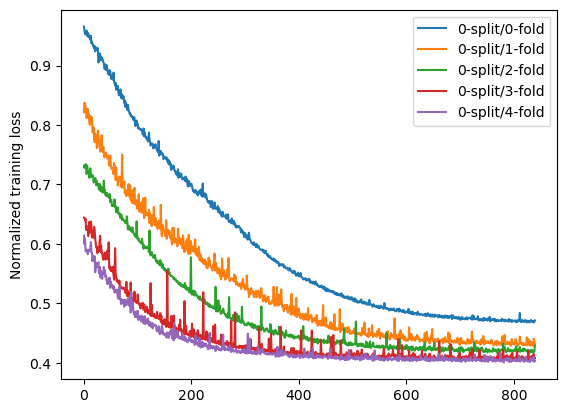

In [107]:
start=time.time()

for model_complex in model_complexities[2:3]:
    print('++++++++++++++++++')
    print('Model type:',model_complex)
    
    for data_param_key in [*parameters_for_analysis][:1]:


        ## Select the number of training days for the training method 'training_on_first_x_days'
        parameter_dict=parameters_for_analysis[data_param_key]
        training_days=parameter_dict['training_days']
        print('dataset name: ',data_param_key)

        ## Load the preprocessed + imputed dataset
        data_dir='../data'
        fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
        fname_x=os.path.join(data_dir,fn)
        data=pd.read_csv(fname_x,index_col=0,low_memory=False)


        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=data.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

        
        ## Subset outcome dataframe to patient considered
        outcome_label=data_param_key.split('vars_')[-1].upper()
        target_df=outcome_df.loc[pat_ids,outcome_label]
        target_df=target_df.loc[pat_ids].replace(label2id)
            


        ## Check if result_dict already exists. If yes, load it, if not create a new one
        #fname='../data/'+data_param_key+'_LSTM_class_results.pickle'
        fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model.pickle'
        if os.path.exists(fname) and update_existing_dicts==False:
            with open(fname,'rb') as f:
                result_dict=pickle.load(f)
        
        ## If result_dict doesn't exist yet or we want to update the existing result_dict -> 
        #  create empty result_dict and collect the results in it
        if os.path.exists(fname)==False or update_existing_dicts==True:
            result_dict={}

        ## Check if test_data_results or cv_results already exists -> if not create them
        #for result_type in ['test_data_results','cv_results','feat_importances']:
        #    if result_type not in result_dict.keys():
        #        result_dict[result_type]={}
        

        print('Shape of final data: ',data.shape) 
        print()

        cross_entropy_weights_dict=dict(zip(categorical_map_dict['labels'],categorical_map_dict['weights']))


        
        for period_end_day in period_end_days[-1:]:

            print('============= Period_end_day:',period_end_day,'===============\n')     

            ## Create dicts to collect test data, CV-results and importance scores for all training methods
            train_data_results={}
            test_data_results={}
            

            ## Check if test_data_results or cv_results already exists -> if not create them
            for result_type in ['test_data_results','cv_results','feat_importances']:
                if result_type not in result_dict.keys():
                    result_dict[result_type]={}

            ### TRAIN MODELS AND SAVE CV-RESULTS + TEST DATA RESULTS #####
            ## Check if data already exists for given dataset -> only run training when training hasn't been run yet
            #if training_method not in result_dict['test_data_results'].keys() \
            #    or training_method not in result_dict['cv_results'].keys():

            ## Update previously created dicts with ML results
            train_data_results,test_data_results=train_models(data,target_df,period_end_day,cat_vars_not_to_hot_encode,
                                                              scoring_methods,outcome_label,\
                                                              training_days,random_state,data_split_random_state,\
                                                              test_data_results,train_data_results,lstm_parameters,swa_params,
                                                              data_param_key,cross_entropy_weights_dict,
                                                              model_complex,k_folds,verbose=True,
                                                              cross_validation=cross_validation,
                                                              get_feature_importances=False)


            ## Add results of test data and CV to the result_dict
            result_dict['test_data_results']=test_data_results
            result_dict['train_data_results']=train_data_results 
            result_dict['lstm_parameters']=lstm_parameters
            #result_dict[data_param_key][categorical_map_name]['cv_results']=cv_results  

            ## Save results of ML on the given data
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            #with open(fname, 'wb') as f:
            #    pickle.dump(result_dict, f)      

print('\n\n=======================')
stop=time.time()
t=print_elapsed_time(start,stop)
print('Script duration:',t)  
print('=======================')                  

In [83]:
divmod(20,20)
int((1-swa_params['swa_update_in_cycle_ratio']) *swa_params['swa_lr_cycle_length'])
#int(1-swa_params['swa_update_in_cycle_ratio']*swa_params['swa_lr_cycle_length'])

num_swa_updates_per_epoch=int((1-swa_params['swa_update_in_cycle_ratio']) *swa_params['swa_lr_cycle_length'])
num_swa_updates_per_epoch if num_swa_updates_per_epoch==0 else 1

1

# 5. PLOT RESULTS

## Training

### Plot training loss curves

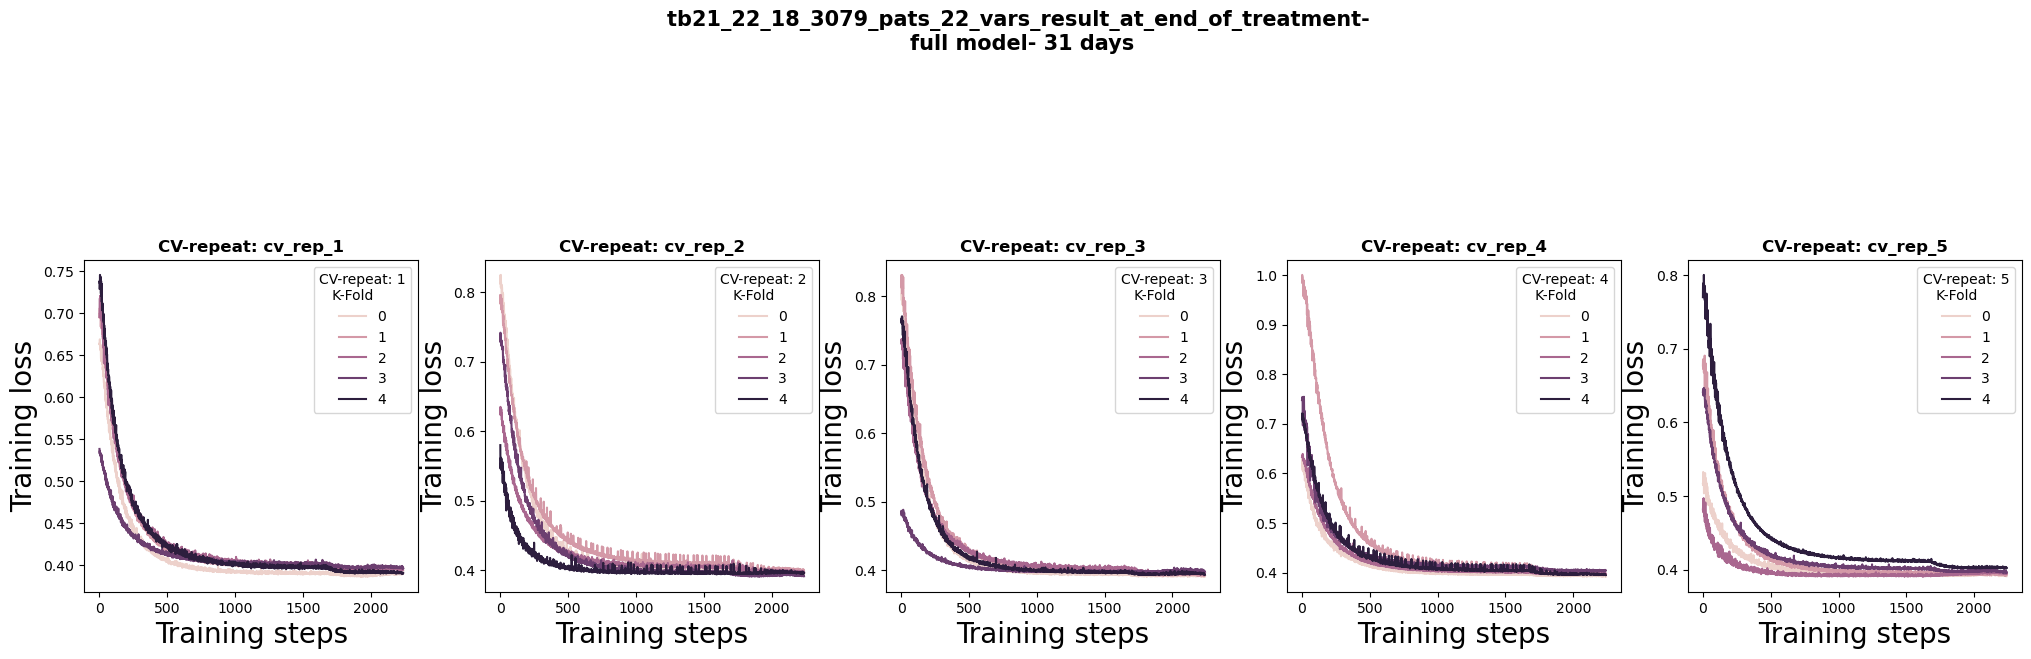

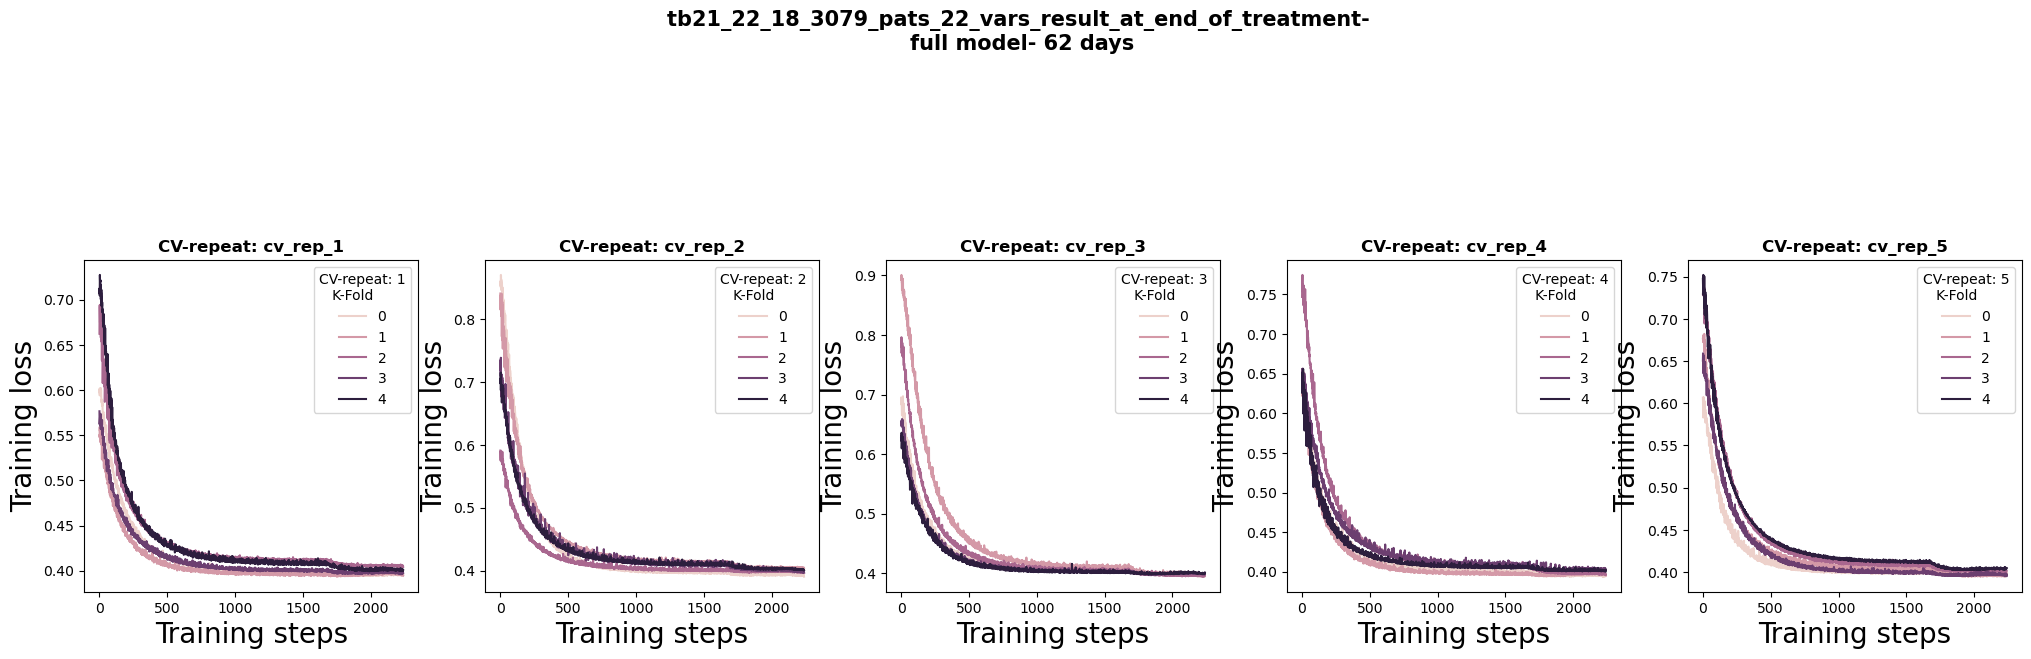

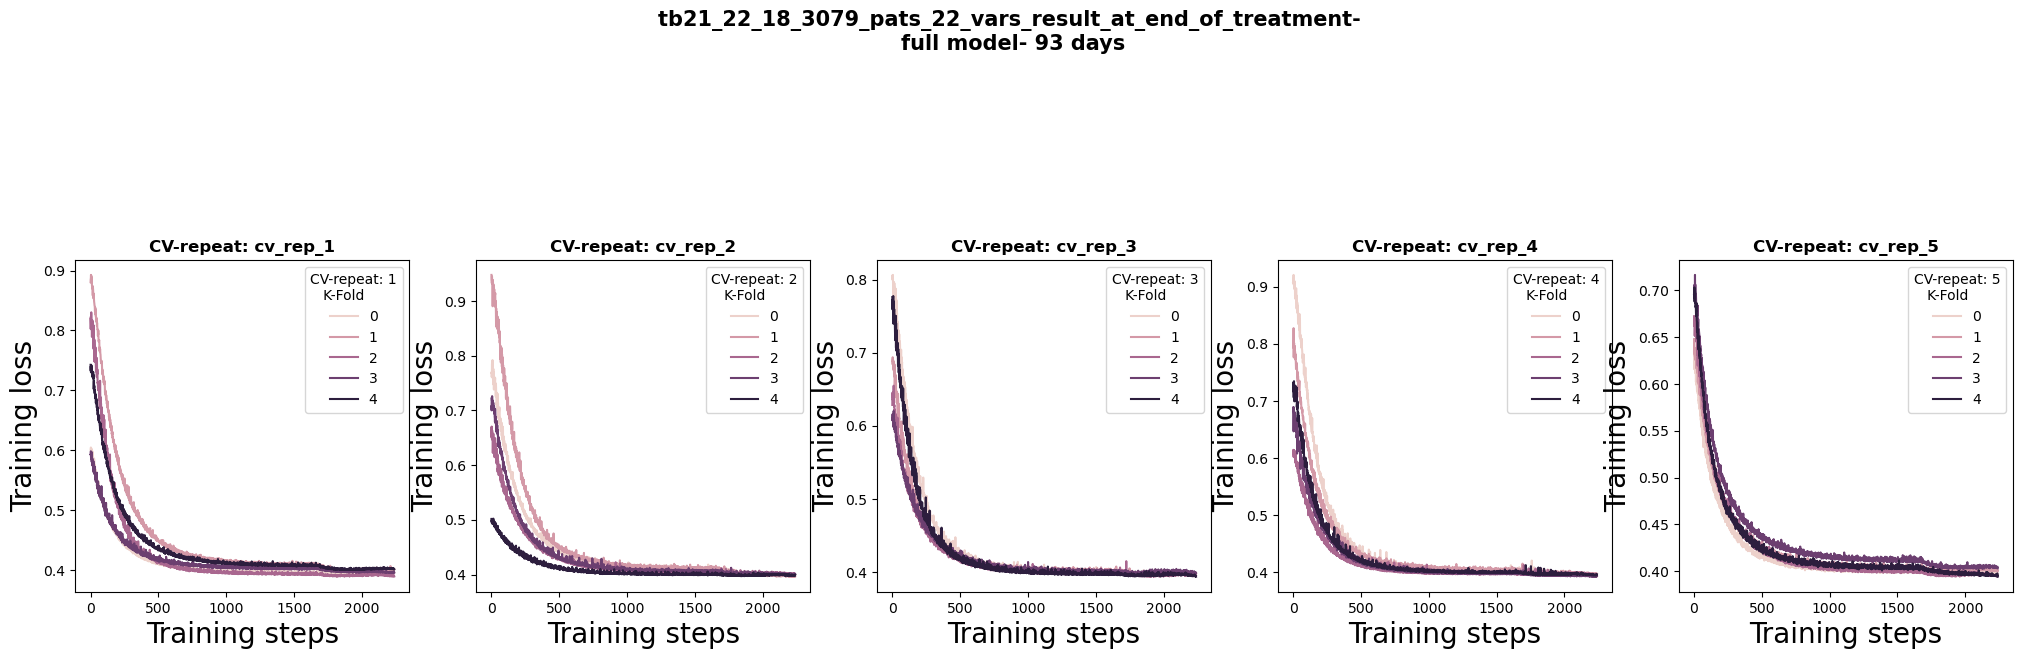

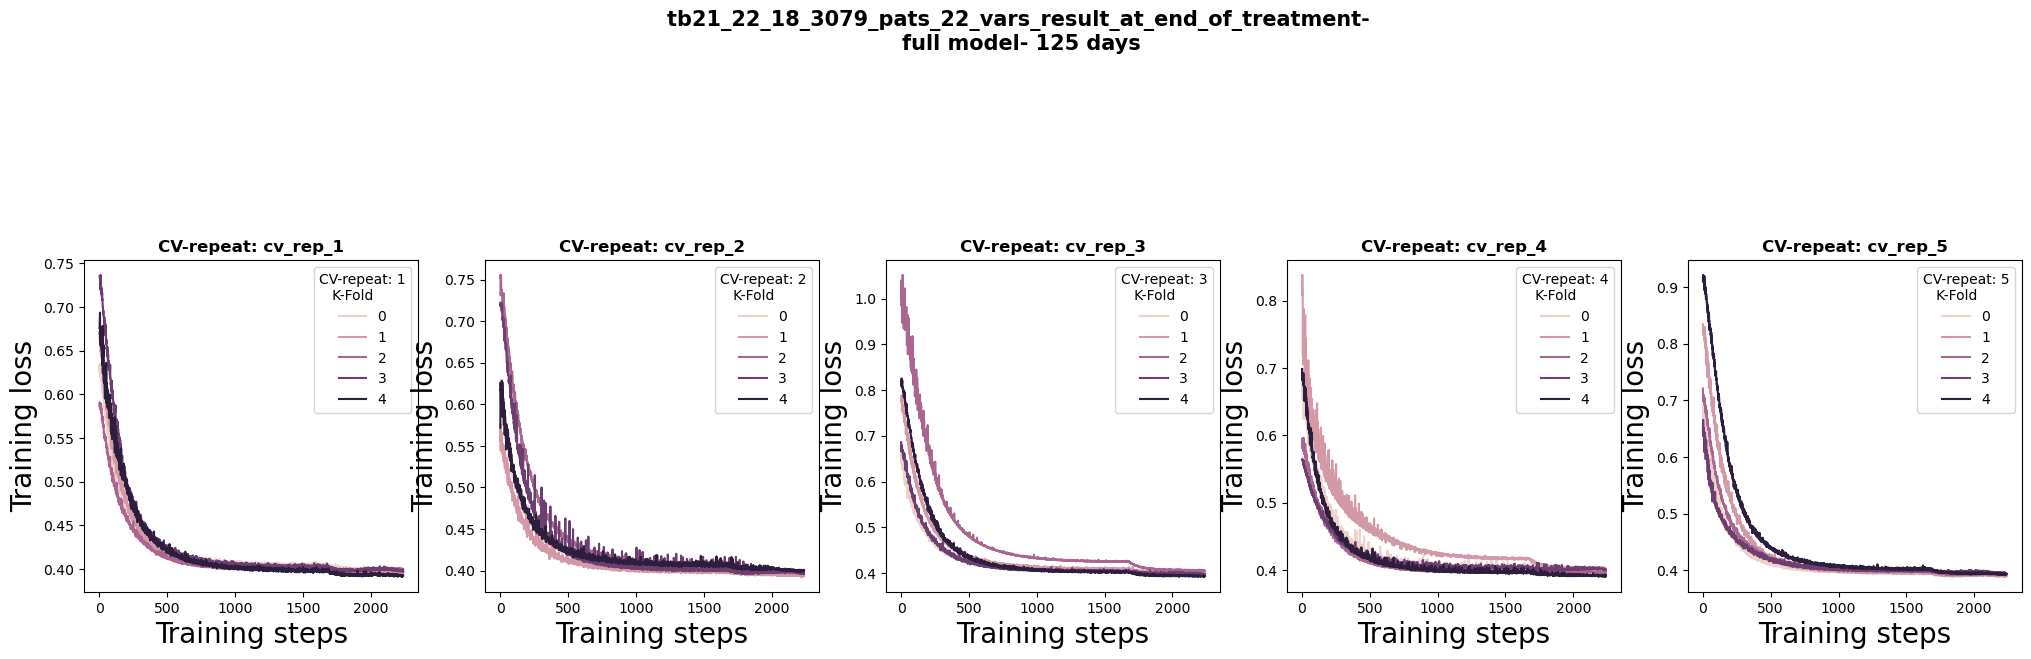

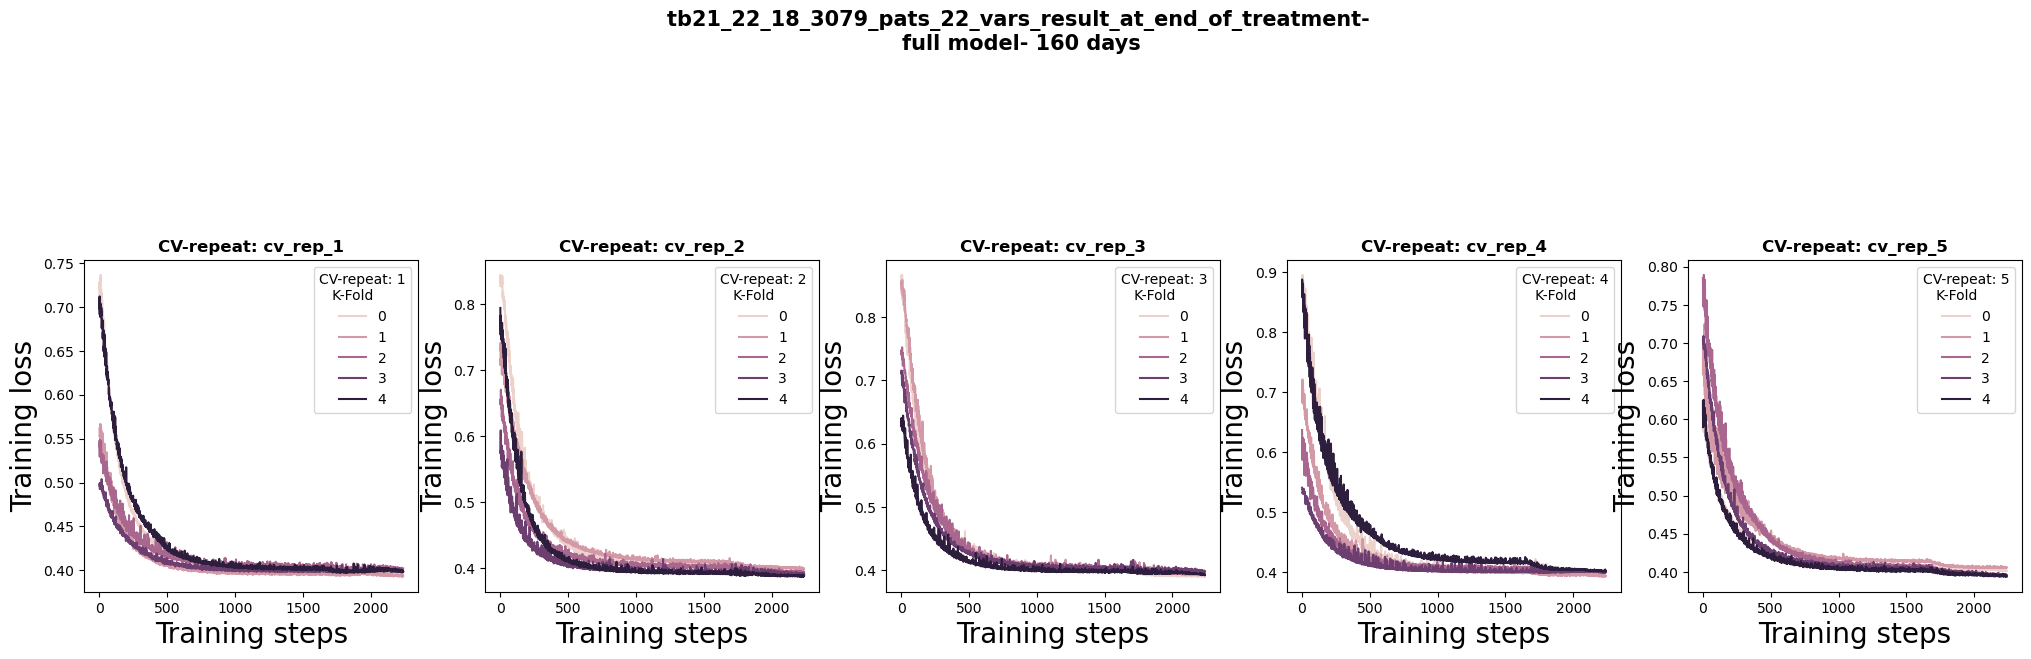

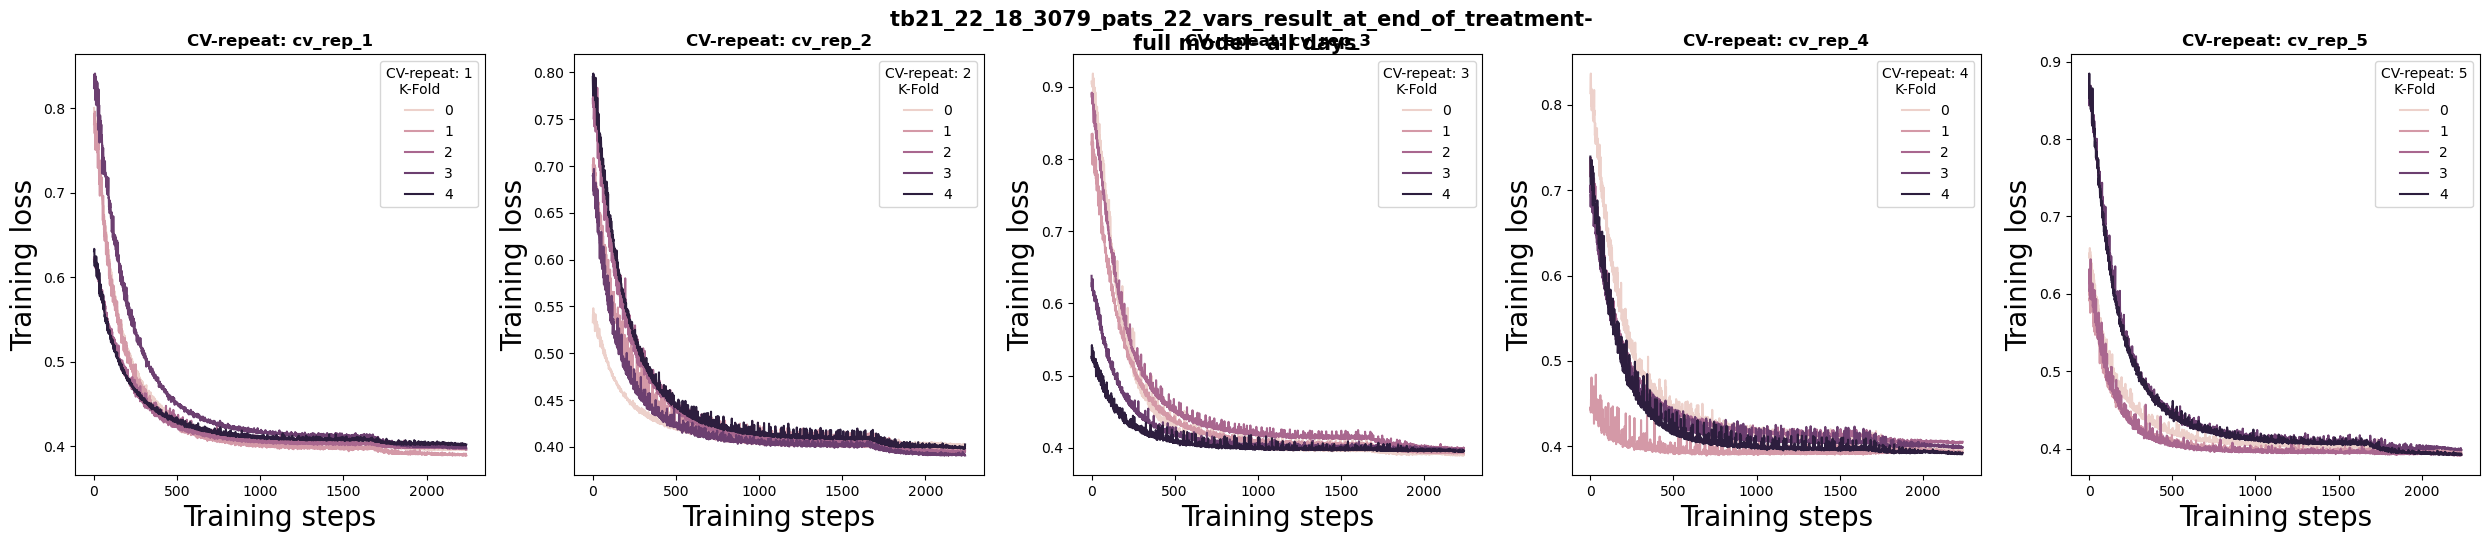

In [93]:
figtitle_size=30
subtitle_size=12
x_tick_size=31
y_tick_size=31
y_label_size=20
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']

for model_complex in model_complexities[2:3]:
    for data_param_key in [*parameters_for_analysis][:1]:

        for period_end_day in period_end_days[:]:

            #fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)   
    
            ncols=num_of_cv_repeats
            nrows=len([*result_dict])
    
            fig=plt.figure(figsize=((ncols)*5,(nrows)*5))
            n=0                        
    

            #categorical_map=categorical_map_dict[categorical_map_name]
            training_data_results=result_dict['train_data_results']


                

            #for train_ds_type in train_dataset_types:
            melted_df_list=[]
            for cv_rep in [*training_data_results][0:]:          
                
                ax=fig.add_subplot(nrows,ncols,n+1)
                n=n+1
                loss_dict=training_data_results[cv_rep]['training_loss']
                # Find the maximum length among the lists
                max_length=max(len(lst) for lst in loss_dict.values())
                # Pad the shorter lists with np.nan values
                padded_loss_dict={key: lst + [np.nan]*(max_length - len(lst)) for key,lst in loss_dict.items()}

                df=pd.DataFrame.from_dict(padded_loss_dict)
                melted_df=pd.melt(df.reset_index(),id_vars='index',var_name='K-Fold',value_name='Training loss')
                melted_df['CV-repeat']=cv_rep.split('_')[-1]

                plot_df=melted_df.copy()#pd.concat(melted_df_list,axis=0)
                if 'no_CV' in cv_rep:

                    plot_df=plot_df.drop(columns=['K-Fold'])
                    sns.lineplot(data=plot_df,y='Training loss',x='index',ax=ax)
                    ax_title='No CV'

                if 'no_CV' not in cv_rep:
                    if num_of_cv_repeats==1:
                        sns.lineplot(data=plot_df,y='Training loss',x='index',hue='K-Fold',ax=ax)
                        ax_title='CV-repeat: '+str(cv_rep)                                                        

                    if num_of_cv_repeats>1:
                        sns.lineplot(data=plot_df,y='Training loss',x='index',hue='K-Fold',ax=ax)
                        handles, labels = ax.get_legend_handles_labels()
                        ax.legend(handles=handles, labels=labels, title=f"CV-repeat: " + str(cv_rep.split('_')[-1]) +'\n   K-Fold')
                        ax_title='CV-repeat: '+str(cv_rep)

                ax.set_title(ax_title,fontsize=subtitle_size,fontweight='bold')
                ax.set_ylabel('Training loss',fontsize=y_label_size)
                ax.set_xlabel('Training steps',fontsize=y_label_size)

                

                fig.suptitle('- '.join([data_param_key,'\n'+model_complex+' model',str(period_end_day)+' days']),fontsize=15,fontweight='bold')     

plt.tight_layout() 
        

### Plot learning rate schedule

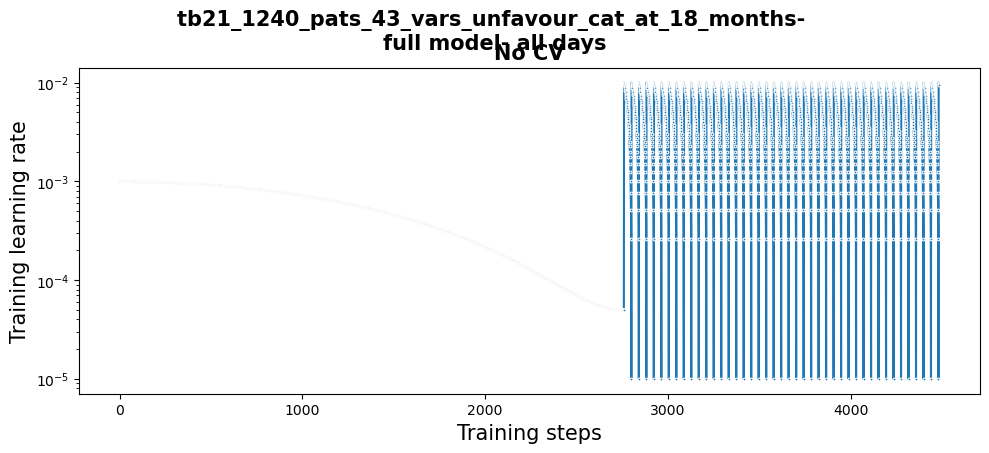

In [28]:
figtitle_size=30
subtitle_size=15
x_tick_size=31
y_tick_size=31
y_label_size=15
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']
for model_complex in model_complexities[2:3]:
    for data_param_key in [*parameters_for_analysis][-2:-1]:

        for period_end_day in period_end_days[-1:]:

            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)     
    
            ncols=num_of_cv_repeats
            nrows=len([*result_dict])
            fig=plt.figure(figsize=((ncols)*10,(nrows)*4))
            n=0


            training_data_results=result_dict['train_data_results']              


            for training_method in training_methods[:1]:
            
                melted_df_list=[]
                for cv_rep in [*training_data_results][0:]:          
                    
                    ax=fig.add_subplot(nrows,ncols,n+1)
                    n=n+1
                    loss_dict=training_data_results[cv_rep]['training_learning_rate']
                    # Find the maximum length among the lists
                    max_length=max(len(lst) for lst in loss_dict.values())
                    # Pad the shorter lists with np.nan values
                    padded_loss_dict={key: lst + [np.nan]*(max_length - len(lst)) for key,lst in loss_dict.items()}

                    df=pd.DataFrame.from_dict(padded_loss_dict)
                    melted_df=pd.melt(df.reset_index(),id_vars='index',var_name='K-Fold',value_name='Training learning rate')
                    melted_df['CV-repeat']=cv_rep.split('_')[-1]

                    plot_df=melted_df.copy()#pd.concat(melted_df_list,axis=0)
                    if 'no_CV' in cv_rep:
                        plot_df=plot_df.drop(columns=['K-Fold'])
                        sns.lineplot(data=plot_df,y='Training learning rate',x='index',ax=ax,marker='o',markersize=2)
                        ax_title='No CV'

                    if 'no_CV' not in cv_rep:
                        if num_of_cv_repeats==1:
                            sns.lineplot(data=plot_df,y='Training learning rate',x='index',hue='K-Fold',ax=ax,marker='o',markersize=2)
                            ax_title='CV-repeat: '+str(cv_rep) 

                        if num_of_cv_repeats>1:
                            sns.lineplot(data=plot_df,y='Training learning rate',x='index',hue='K-Fold',ax=ax)
                            handles, labels = ax.get_legend_handles_labels()
                            ax.legend(handles=handles, labels=labels, title=f"CV-repeat: " + str(cv_rep.split('_')[-1]) +'\n   K-Fold')
                            ax_title='CV-repeat: '+str(cv_rep)

                    ax.set_title(ax_title,fontsize=subtitle_size,fontweight='bold')
                    ax.set_ylabel('Training learning rate',fontsize=y_label_size)
                    ax.set_xlabel('Training steps',fontsize=y_label_size)
                    #ax.set_xlim(900,)
                    ax.set_yscale('log')
                    

                    #fig.suptitle('- '.join([ds_name,model_complex+' model']),fontsize=15,fontweight='bold')    
                    fig.suptitle('- '.join([data_param_key,'\n'+model_complex+' model',str(period_end_day)+' days']),fontsize=15,fontweight='bold')  
 
plt.tight_layout() 

### Plot CV results

#### ROC-AUC of all timepoints

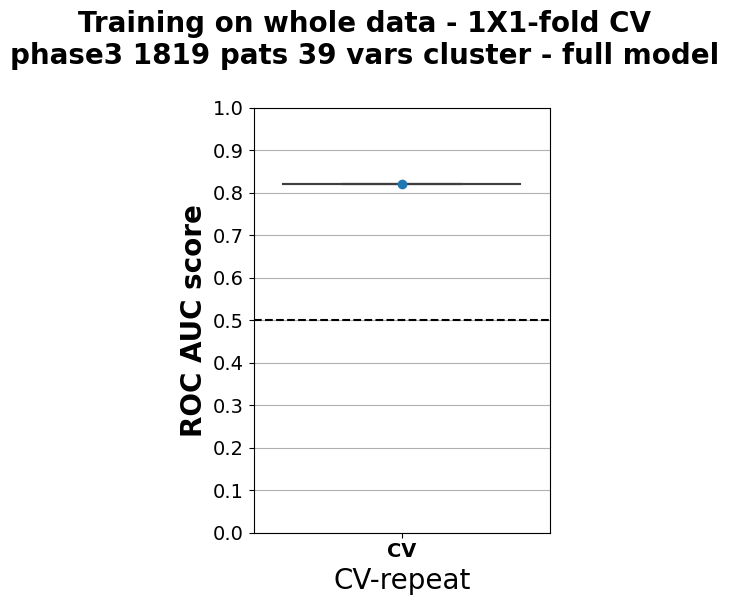

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
import matplotlib as mpl
from sklearn.metrics import roc_auc_score

figtitle_size=20
subplot_title_size=16
ylabel_size=12
text_size=18
legend_title_fontsize=13
scatter_dot_size=10
dot_size=7
x_tick_size=14
y_tick_size=14


model_names=['LSTM']
#train_dataset_types=['raw','log']

color_by='DAY'
color_by_legend_title={'STUDYID':'Study','DAY':'Study day','ARM':'Arm','PHASE':'Phase','USUBJID':'SubjectID'}
training_method_fig_title={'training_on_whole_data':'Trained on all study days - Predicting TTP on all study days',
                           'training_on_first_x_days':'Trained on up until day'}


for model_complex in model_complexities[2:3]:
    for ds_name in [*parameters_for_analysis][-2:-1]:

        fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
        if os.path.exists(fname):
            with open(fname,'rb') as f:
                result_dict=pickle.load(f)
        
        for categorical_map_name in [*result_dict][:1]:
            categorical_map=categorical_map_dict[categorical_map_name]
            training_data_results=result_dict[categorical_map_name]['train_data_results']

            df_list=[]
            for training_method in training_methods[:1]:  

                if training_method=='training_on_first_x_days':
                    training_days=training_data_results['training_on_first_x_days']['training_days']
                
                cv_results={}
                #for train_ds_type in train_dataset_types:
                
                roc_list,cv_rep_list=[],[]

                for cv_rep in [*training_data_results[training_method]]:
                    k_fold_results=training_data_results[training_method][cv_rep]['results']['validation']
                    
                    n=0
                    
                    for k_fold in [*k_fold_results]:
                        #print(k_fold_results[k_fold].keys())

                        model_name='LSTM'
                        actual_y=model_name+'_y'
                        #y_train_name=model_name+'_y_with_index'
                        predicted_label=model_name+'_predicted_label'
                        predicted_prob=model_name+'_predicted_prob'
                        cross_entropy_weights_dict=model_name+'_cross_entropy_weights_dict'
                        sample_weights=np.vectorize(k_fold_results[k_fold][cross_entropy_weights_dict].get)(k_fold_results[k_fold][predicted_label])


                        auc_score=roc_auc_score(y_true=k_fold_results[k_fold][actual_y],
                                                y_score=np.array(k_fold_results[k_fold][predicted_prob])[:,1],
                                                sample_weight=sample_weights,
                                                average='macro')


                        roc_list.append(round(auc_score,3))
                        cv_rep_list.append(cv_rep.split('_')[-1])

                cv_results['ROC_AUC_score']=roc_list
                cv_results['CV-repeat']=cv_rep_list

                df=pd.DataFrame.from_dict(cv_results)
                #df['Training type']=train_ds_type + ' TTP'
                df_list.append(df)

        ## Concatenate datqaframes of different training dataset types (i.e.raw TTP - log TTP)
        plot_df=pd.concat(df_list,axis=0)        


        metrics=['ROC_AUC_score'][0:]
        ncols=len(metrics)
        nrows=1
        fig=plt.figure(figsize=(nrows*4,ncols*6))

        for n,scoring_method in enumerate(metrics[0:]):
            ax=fig.add_subplot(nrows,ncols,n+1)
            sns.boxplot(data=plot_df,y=scoring_method,x='CV-repeat',ax=ax,boxprops={'facecolor':'none'})
            sns.swarmplot(data=plot_df,y=scoring_method,x='CV-repeat',ax=ax,s=dot_size,dodge=False)
            
            ## If no multiple CV repeats, then don't color by the CV-repeats column
            #if len(plot_df['CV-repeat'].unique())==1:
            #    sns.swarmplot(data=plot_df,y=scoring_method,x='CV-repeat',ax=ax,s=dot_size,dodge=False)
            #if len(plot_df['CV-repeat'].unique())>1:
            #    sns.swarmplot(data=plot_df,y=scoring_method,x='Training type',ax=ax,hue='CV-repeat',s=dot_size,dodge=False)

            ax.set_ylabel(scoring_method.replace('_',' '),fontsize=y_label_size,fontweight='bold')
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=x_tick_size,fontweight='bold',rotation=0)

            ax.set_ylim(0,1)
            ax.set_yticks(np.linspace(0,ax.get_ylim()[1],11))
            ax.set_yticklabels(np.round(np.linspace(0,ax.get_ylim()[1],11),2),fontsize=y_tick_size)
            #title=train_data_type.split('_train')[0]+' TTP values'
            #ax.set_title(title,fontsize=subtitle_size,fontweight='bold')
            ax.set_xlabel('CV-repeat',fontsize=y_label_size)
            #ax.set_xlabel(None)
            ax.axhline(0.5,linestyle='--',color='black')
            ax.grid(axis='y',which='both')
            plt.tight_layout

    if training_method=='training_on_first_x_days':
        suptitle=training_method.replace('x',str(training_days))
        suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV'+'\n'+\
                    ds_name.replace('_',' ')+ ' - '+model_complex+' model'
                    
    else:
        suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV'+\
                    '\n'+ds_name.replace('_',' ') + ' - '+model_complex+' model'
    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1)        
   
plt.tight_layout()

#### ROC-AUC of per visit

In [36]:
len(training_data_results['cv_rep_1']['cv_training_ids'])#.keys()#['results']['training'].keys()#[0].keys()#[training_method][cv_rep]['results'].keys()
#result_dict['train_data_results'].keys()

5

/tmp/ipykernel_210809/4134145991.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
/tmp/ipykernel_210809/4134145991.py:203: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['model_name']='LSTM'
/tmp/ipykernel_210809/4134145991.py:224: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
/tmp/ipykernel_210809/4134145991.py:203: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

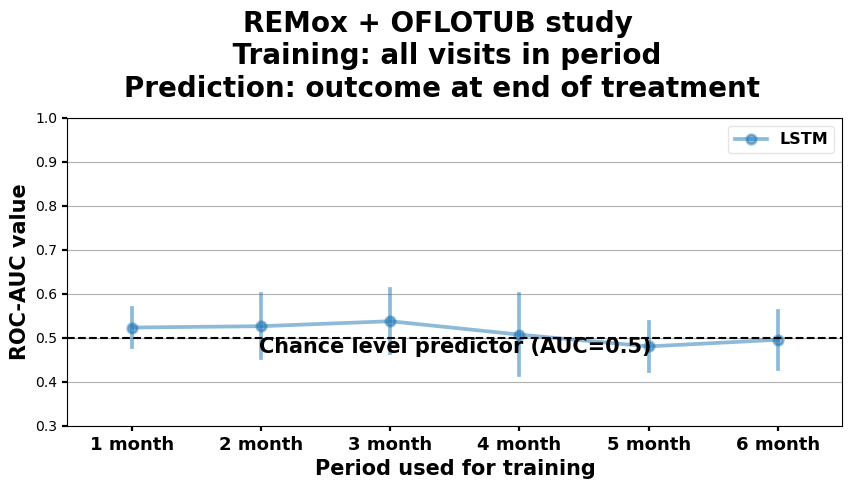

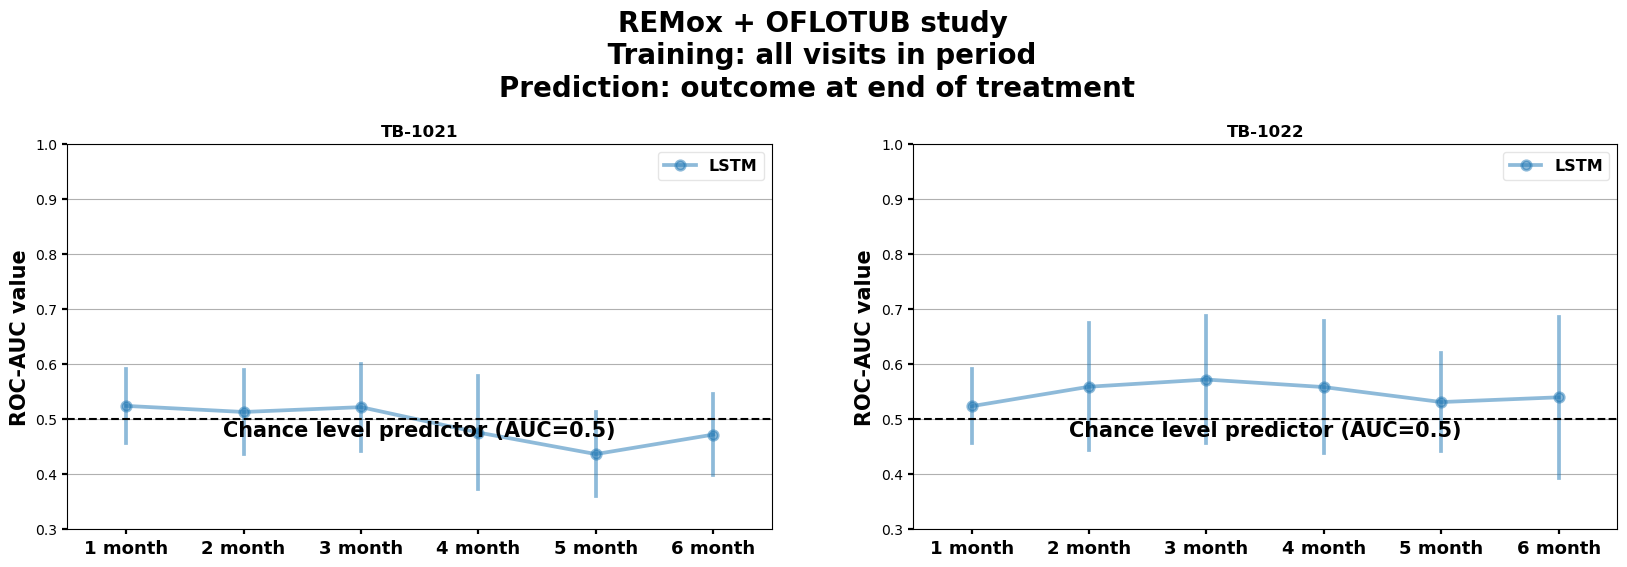

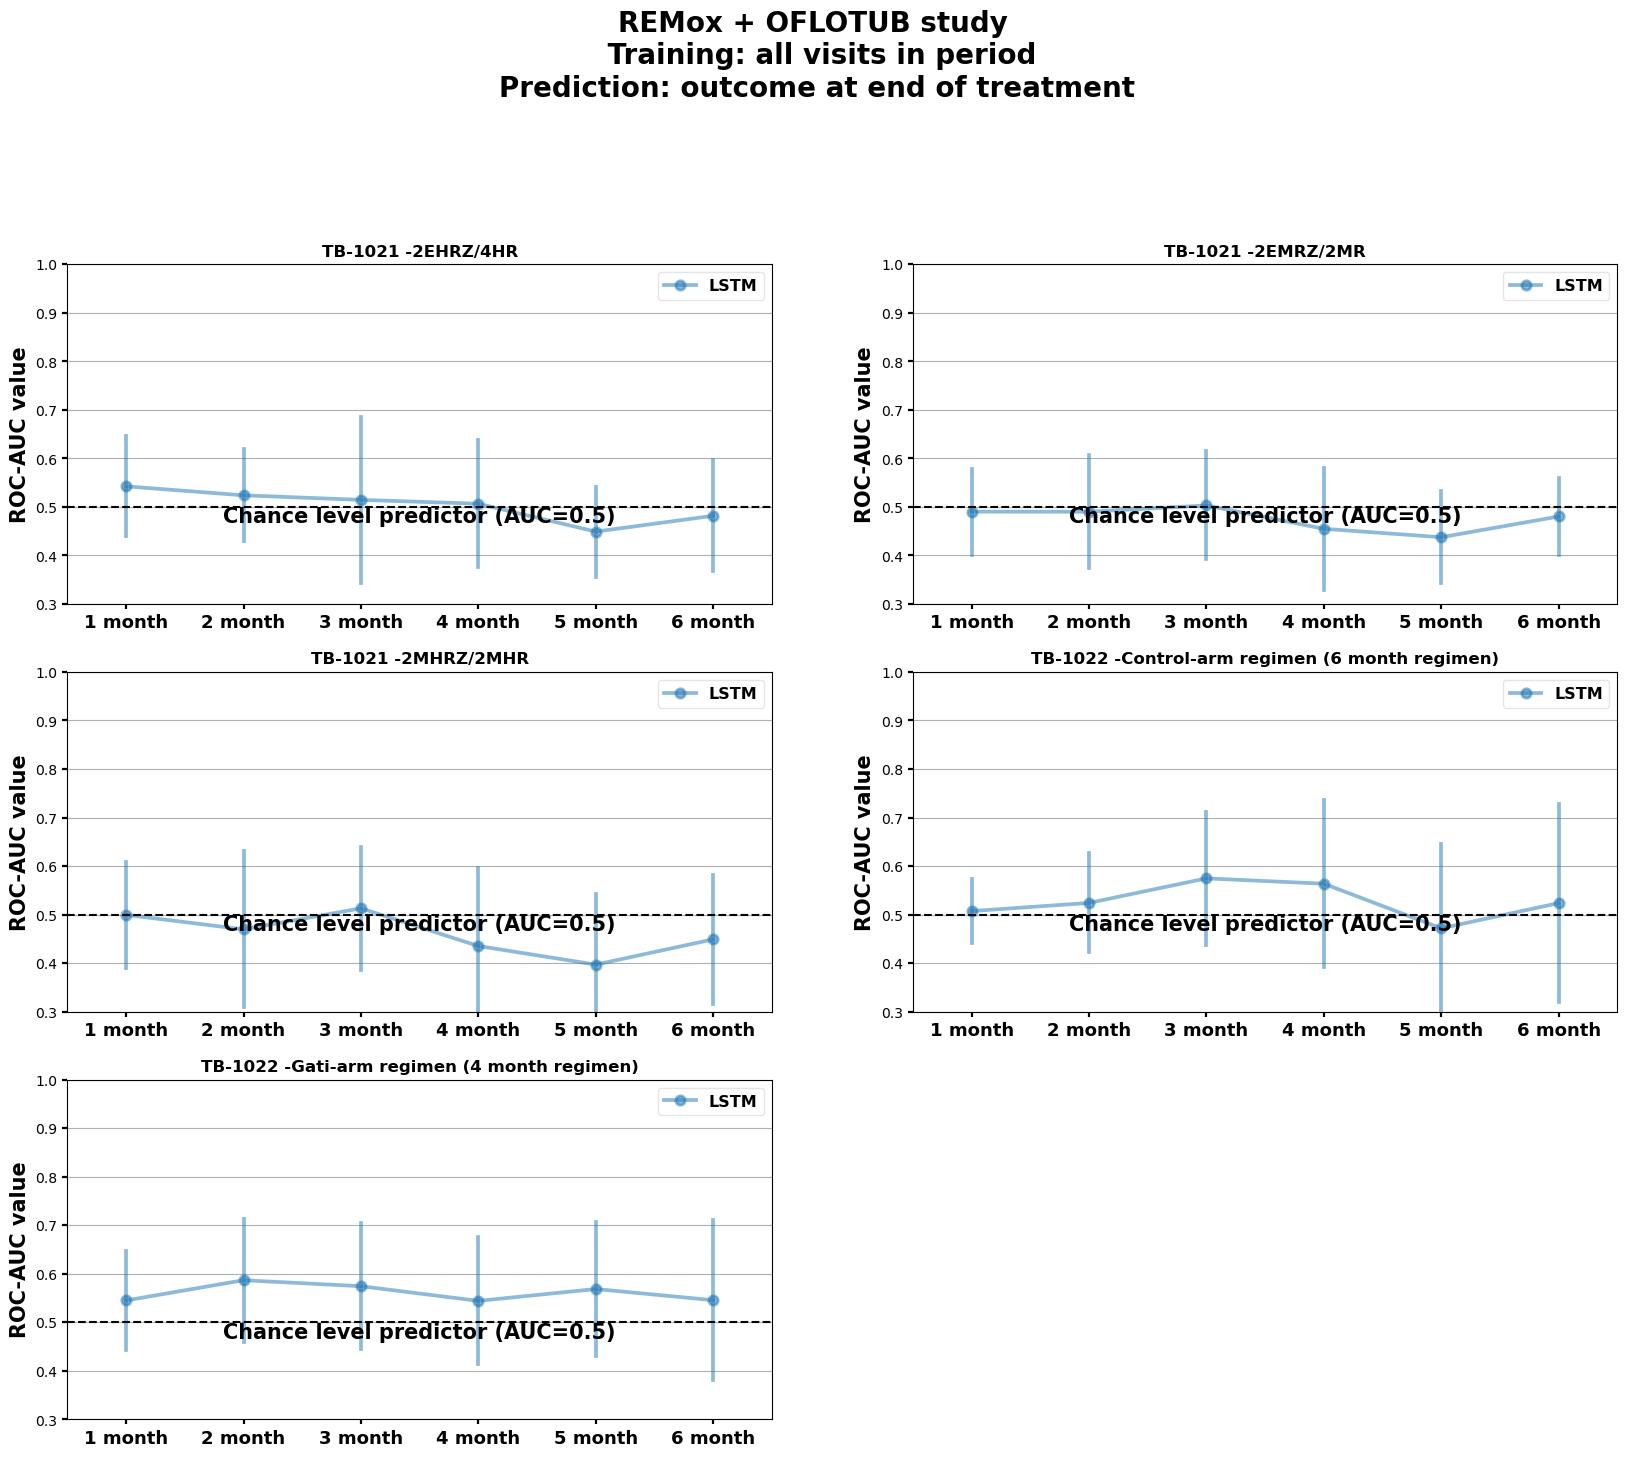

In [92]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import matplotlib as mpl
from sklearn.metrics import roc_auc_score
import itertools


figtitle_size=20
subtitle_size=18
x_tick_size=13
y_tick_size=13
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6



model_names=['LSTM']
#train_dataset_types=['raw','log']
period_end_days_for_plot=period_end_days[:]

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}


color_by='DAY'
color_by_legend_title={'STUDYID':'Study','DAY':'Study day','ARM':'Arm','PHASE':'Phase','USUBJID':'SubjectID'}
training_method_fig_title={'training_on_whole_data':'Trained on all study days - Predicting TTP on all study days',
                           'training_on_first_x_days':'Trained on up until day'}


for model_complex in model_complexities[2:3]:
    for data_param_key in [*parameters_for_analysis][:1]:

        outcome_label=data_param_key.split('vars_')[-1].upper()

        l_all,l_study,l_arm=[],[],[]

        ncols=1 #len([*training_data_results[training_method]])
        nrows=1
        fig,ax=plt.subplots(1,1,figsize=(ncols*10,nrows*4))
        
        for period_end_day in period_end_days[:]:

            #fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)
        

            training_data_results=result_dict['train_data_results']

                
            cv_results={}
            #for train_ds_type in train_dataset_types:
            
            df_list,cv_rep_list=[],[]
            

            roc_scores_all_cv_list,roc_scores_study_cv_list,roc_scores_arm_cv_list=[],[],[]
            
            for cv_rep in [*training_data_results]:
                cv_results[cv_rep.split('_')[-1]]={}
                k_fold_results=training_data_results[cv_rep]['results']['validation']
                roc_list,visit_list=[],[]
                n=0

                roc_scores_all_list,roc_scores_study_list,roc_scores_arm_list=[],[],[]
                
                for k_fold in [*k_fold_results]:
                    #print(k_fold_results[k_fold].keys())

                    model_name='LSTM'
                    actual_y='y'
                    actual_y_with_index='y_with_index'
                    predicted_label='predicted_label'
                    predicted_prob='predicted_prob'
                    cross_entropy_weights_dict='cross_entropy_weights_dict'
                    x_test_name='x'
                    sample_weights=np.vectorize(k_fold_results[k_fold][cross_entropy_weights_dict].get)(k_fold_results[k_fold][predicted_label])


                    predicted_prob=list(chain(*training_data_results[cv_rep]['results']['training'][k_fold]['predicted_prob']))
                    y_with_index=training_data_results[cv_rep]['results']['training'][k_fold]['y_with_index']

                    x_for_test=training_data_results[cv_rep]['results']['training'][k_fold]['x']
                    train_ids=x_for_test['USUBJID'].drop_duplicates()
                    y_with_index_=y_with_index.reset_index().set_index('USUBJID')

                    
                    y_with_index_=y_with_index_.loc[train_ids,:]
                    y_with_index_['predicted_prob']=predicted_prob


                    roc_scores_all = roc_auc_score(y_with_index_[outcome_label].values,y_with_index_['predicted_prob'].values)
                    roc_scores_study = y_with_index_.groupby('STUDYID').apply(lambda x: roc_auc_score(x[outcome_label].values,x['predicted_prob'].values)).to_frame()    
                    roc_scores_arm = y_with_index_.groupby(['ARM','STUDYID']).apply(lambda x: roc_auc_score(x[outcome_label].values,x['predicted_prob'].values)).to_frame()

                    
                    roc_scores_study['CV_rep']=cv_rep 
                    roc_scores_arm['CV_rep']=cv_rep 

                    #print(roc_scores_study)

                    roc_scores_all_list.append(roc_scores_all)
                    roc_scores_study_list.append(roc_scores_study)
                    roc_scores_arm_list.append(roc_scores_arm)

                
                roc_df_all_cv=pd.DataFrame(data=roc_scores_all_list,columns=['ROC_AUC_score'])
                roc_df_all_cv['CV_rep']=cv_rep
                
                roc_df_study_cv=pd.concat(roc_scores_study_list,axis=0)
                roc_df_study_arm=pd.concat(roc_scores_arm_list,axis=0)

                roc_scores_all_cv_list.append(roc_df_all_cv)
                roc_scores_study_cv_list.append(roc_df_study_cv)
                roc_scores_arm_cv_list.append(roc_df_study_arm)

            roc_all_df=pd.concat(roc_scores_all_cv_list,axis=0)
            roc_study_df=pd.concat(roc_scores_study_cv_list,axis=0)
            roc_arm_df=pd.concat(roc_scores_arm_cv_list,axis=0)

            for df in [roc_all_df,roc_study_df,roc_arm_df]:
                df['inclusion_period']=period_end_day

            l_all.append(roc_all_df)
            l_study.append(roc_study_df)
            l_arm.append(roc_arm_df)

        ## Collect all the ROC-AUC values into dataframes (calucalted over all samples, per study, per arm)
        plot_df=pd.concat(l_all,axis=0)
        plot_df_study=pd.concat(l_study,axis=0)
        plot_df_arm=pd.concat(l_arm,axis=0)

        plot_df['model_name']='LSTM'
        
        ## Plot ROC-AUC calculated over all samples
        sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                  errorbar='sd',alpha=0.5)

        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days_for_plot]
        ax.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 

        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.yaxis.grid(True) 
        
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        ## Remove legend title

        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})

        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            #train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: all visits in period\nPrediction: outcome at {prediction_time}"
            
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
            
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  


       


        ### =======  PLOT PER-STUDY ROC-AUC VALUES IF MULTIPLE STUDIES WERE IN TRAINING DATASET ======= #####
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLO
        scores_per_study_list=plot_df_study.reset_index()['STUDYID'].unique()
        
        if len(scores_per_study_list)>0:# and plot_split_by_studies==True:

            cv_res_per_study_df=plot_df_study.reset_index().rename(columns={0:'ROC_AUC_score'})
            ncols=len(cv_res_per_study_df['STUDYID'].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))

            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                plot_df['model_name']='LSTM'

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('inclusion_period')['ROC_AUC_score'].median().reset_index()

                #sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''

                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.3,1) 

                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  


        ### =======  PLOT PER-STUDY ROC-AUC VALUES IF MULTIPLE STUDIES WERE IN TRAINING DATASET ======= #####
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        if len(scores_per_study_list)>0:# and plot_split_by_studies==True:

            cv_res_per_arm_df=plot_df_arm.reset_index().rename(columns={0:'ROC_AUC_score'})
            ncols=2
            num_of_arms=len(cv_res_per_arm_df['ARM'].unique())
            nrows=int(np.ceil(num_of_arms/ncols))
            fig3=plt.figure(figsize=(ncols*10,nrows*5))

            for n,arm in enumerate(cv_res_per_arm_df['ARM'].unique()):
                ax3=fig3.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_arm_df[cv_res_per_arm_df['ARM']==arm]
                plot_df['model_name']='LSTM'

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('inclusion_period')['ROC_AUC_score'].median().reset_index()

                #sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax3,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''

                studyid=plot_df['STUDYID'].unique()[0]
                ax3.set_title(f'{studyid} -{arm}',fontweight='bold')
                ax3.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax3.set_xlabel(None)
                ax3.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax3.set_ylim(0.3,1) 

                # increase tick width
                ax3.tick_params(width=axis_lw)
                ax3.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax3.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax3.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax3.get_legend_handles_labels()
                legend = ax3.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax3.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig3.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  


In [88]:
cv_res_per_arm_df
#plot_df_study.reset_index().rename(columns={0:'ROC_AUC_score'})
#roc_arm_df
#roc_df_study_arm
#y_with_index_.groupby('ARM').apply(lambda x: roc_auc_score(x[outcome_label].values,x['predicted_prob'].values))
#len(predicted_prob)

#x_for_test['USUBJID'].drop_duplicates()#.unique().shape
#len(train_ids)

,ARM,STUDYID,ROC_AUC_score,CV_rep,inclusion_period
0,2EHRZ/4HR,TB-1021,0.495971,cv_rep_1,31
1,2EMRZ/2MR,TB-1021,0.356884,cv_rep_1,31
2,2MHRZ/2MHR,TB-1021,0.467297,cv_rep_1,31
3,Control-arm regimen (6 month regimen),TB-1022,0.403353,cv_rep_1,31
4,Gati-arm regimen (4 month regimen),TB-1022,0.471354,cv_rep_1,31
...,...,...,...,...,...
745,2EHRZ/4HR,TB-1021,0.576389,cv_rep_5,all
746,2EMRZ/2MR,TB-1021,0.518490,cv_rep_5,all
747,2MHRZ/2MHR,TB-1021,0.299361,cv_rep_5,all
748,Control-arm regimen (6 month regimen),TB-1022,0.551351,cv_rep_5,all


### Plot results of training data

1.0    3784
0.0      19
Name: LSTM_y, dtype: int64
0.0    2621
1.0    1052
2.0      87
6.0      19
3.0      16
5.0       6
4.0       2
Name: LSTM_y, dtype: int64


/Users/daniel.garger/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/daniel.garger/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


'\n        \n'

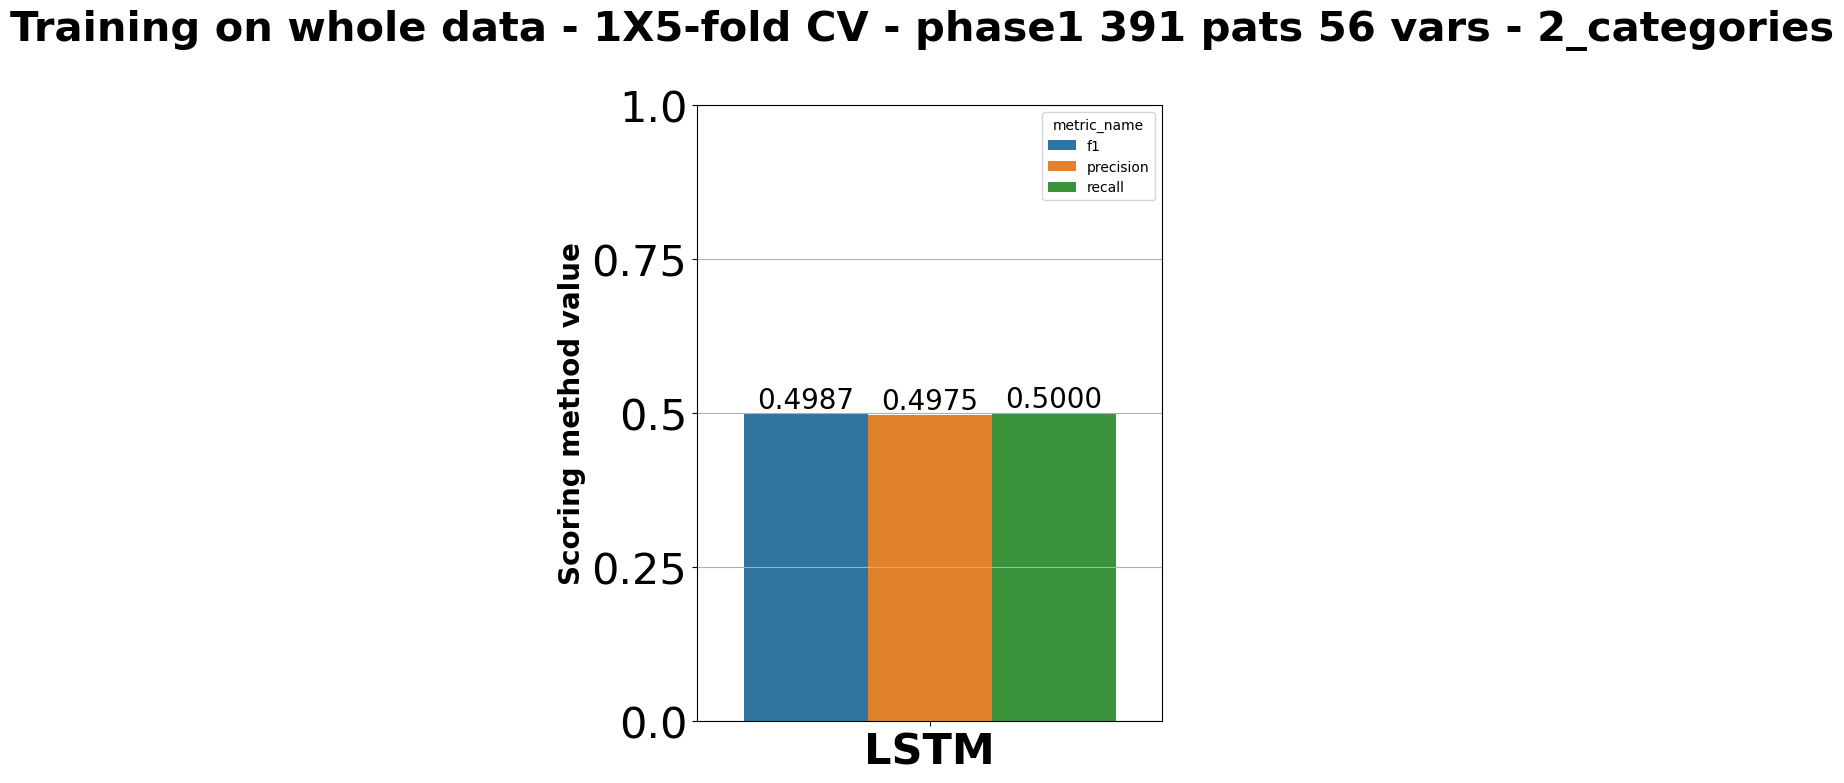

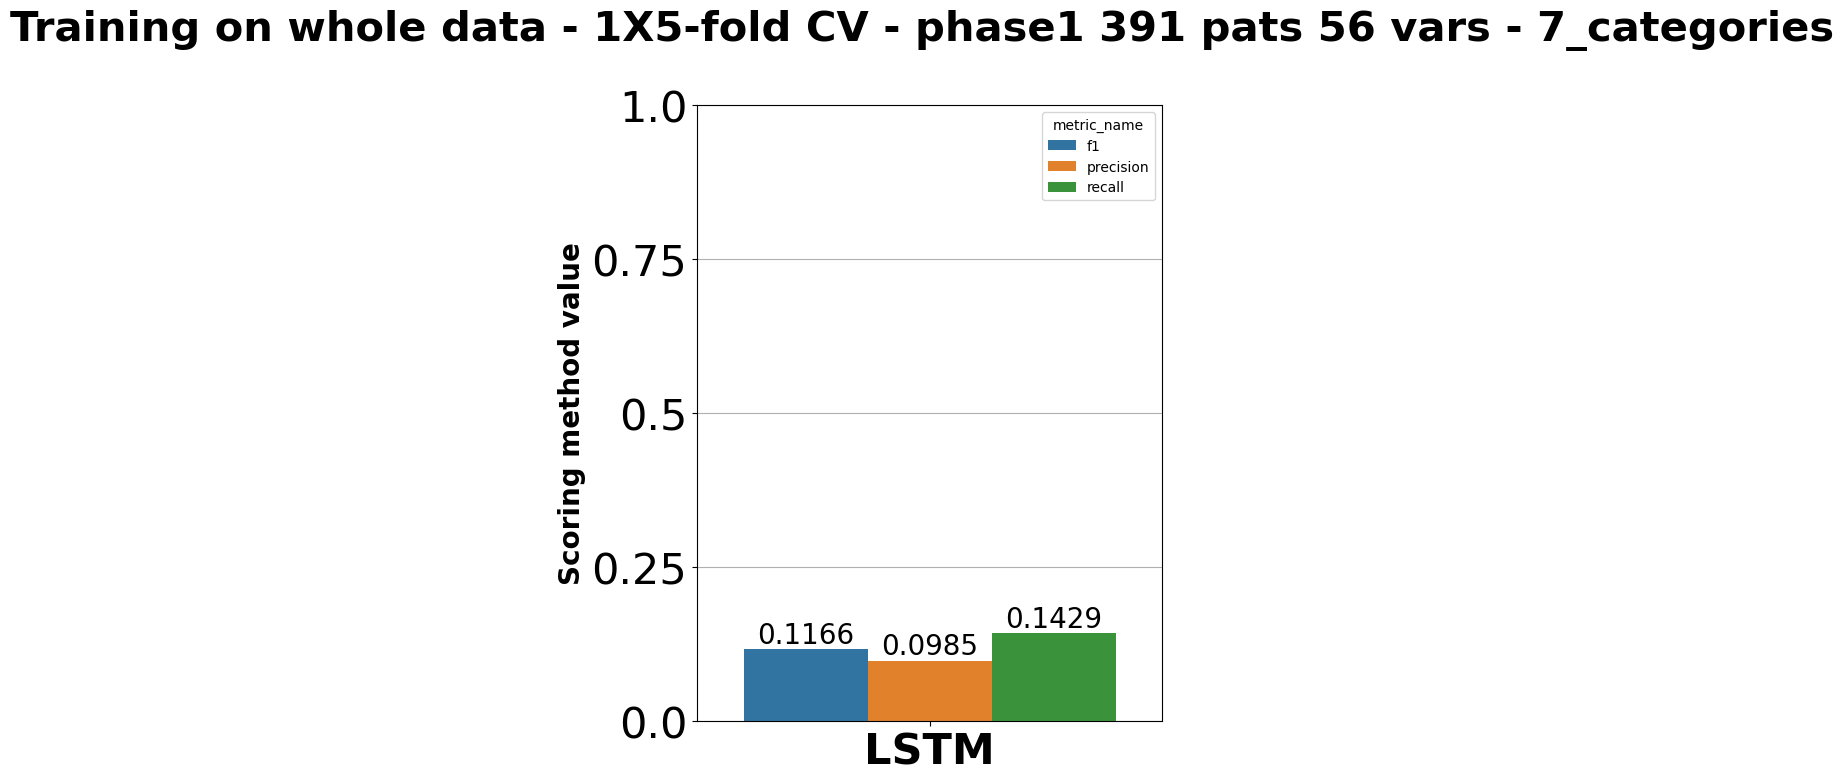

In [100]:
figtitle_size=30
#subtitle_size=20
x_tick_size=31
y_tick_size=31
y_label_size=20
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']

for ds_name in [*parameters_for_analysis][:1]:
    
    fname='../data/'+ds_name+'_LSTM_class_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)           


    for categorical_map_name in [*categorical_map_dict][:]:
        train_data_results=result_dict[categorical_map_name]['train_data_results']
        #training_days=result_dict['train_data_results']['training_on_first_x_days']['training_days']
        
        for training_method in training_methods[:1]:
            
            plot_dict={key: value for key, value in train_data_results[training_method].items() \
                        if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
            
            pred_df=pd.DataFrame.from_dict(plot_dict)

            fig,axes=plt.subplots(1,1,figsize=(len(model_names)*6,8))
            ax=axes
            plot_df=pd.DataFrame(columns=['model_name','metric_name','metric_value'])
            model_name_list,metric_name_list,metric_value_list=[],[],[]
            for model_name in model_names:
                actual_y=model_name+'_y'
                predicted=model_name+'_predicted'
                print(pred_df[actual_y].value_counts(normalize=False))
                        
                for scoring_method in scoring_methods:
                    scorer=scoring_methods_dict[scoring_method]
                    score_metric_value=scorer(pred_df[actual_y], pred_df[predicted], average='macro')
                    model_name_list.append(model_name)
                    metric_name_list.append(scoring_method)
                    metric_value_list.append(score_metric_value)
                
            plot_df['model_name']=model_name_list
            plot_df['metric_name']=metric_name_list
            plot_df['metric_value']=metric_value_list

            ylim=1.1*(plot_df['metric_value'].max())
            plot_df=plot_df.replace({'RandomForest':'Random\nForest',
                                        'GradientBoost':'Gradient\nBoost',
                                        'LogisticRegression':'Logistic\nRegression',
                                        'DenseNetwork':'Dense\nNetwork',
                                        'ElasticNet':'Elastic\nNet'},regex=True)

            sns.barplot(data=plot_df,x='model_name',y='metric_value',hue='metric_name',ax=ax)
            # Iterate over each bar
            for p in ax.patches:
                # Get the height of the bar
                height = p.get_height()
                
                # Add the y-value on top of the bar
                ax.annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom',fontsize=bar_annot_fontsize)

            ax.set_ylabel('Scoring method value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=x_tick_size,fontweight='bold',rotation=0)
            ax.set_ylim(0,1)
            ax.set_yticks(np.linspace(0,ax.get_ylim()[1],5))
            ax.set_yticklabels(np.round(np.linspace(0,ax.get_ylim()[1],5),2),fontsize=y_tick_size)
            title='TTP values'
            #ax.set_title(title,fontsize=subtitle_size,fontweight='bold')
            ax.grid(axis='y')
            plt.tight_layout

            if training_method=='training_on_first_x_days':
                    suptitle=training_method.replace('x',str(training_days))
                    suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                            
            else:
                suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                        ds_name.replace('_',' ') + ' - '+ categorical_map_name
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1)
            #print(weighted_f1)

'''
        
'''                

### Plot confusion matrices of training data

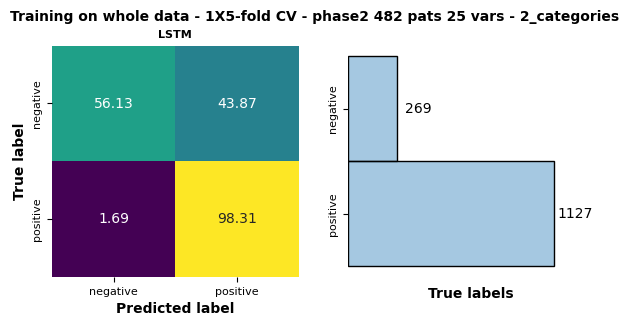

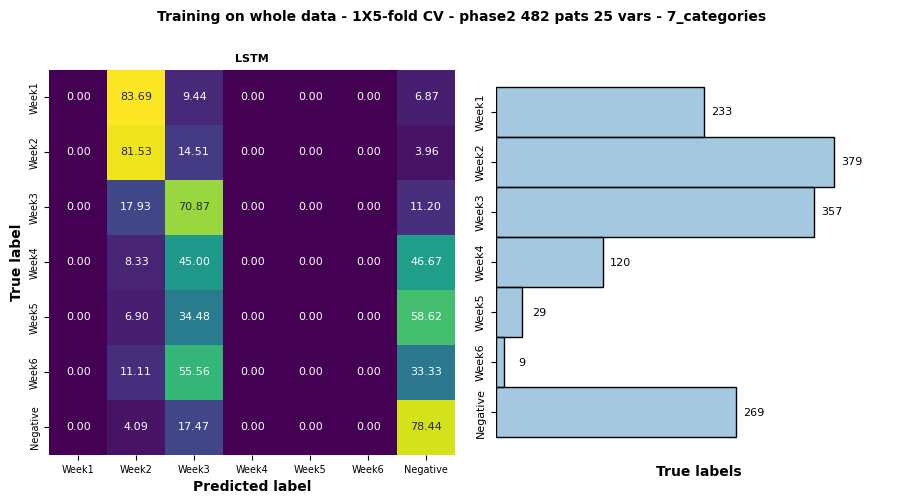

In [124]:
## Set the figtitle sizes  -> the other fontsizes can be found lower in the code 
figtitle_size=10
subtitle_size=8

from sklearn import metrics

model_names=['LSTM']

categorical_map_dict={'2_categories':{'bins':[-1,42,float('inf')],'labels':[1,0],
                                      'labels_str':['positive','negative'],
                                      'weights':[1,1]},
                      '7_categories':{'bins':[-1,1*7,2*7,3*7,4*7,5*7,6*7,float('inf')],'labels':[0,1,2,3,4,5,6],
                                     'labels_str':['Week1','Week2','Week3','Week4','Week5','Week6','Negative'],
                                     'weights':[1,1,1,1,1,1,1]}}


for model_complex in model_complexities[0:1]:
    for ds_name in [*parameters_for_analysis][0:1]:

        fname=f'../data/{ds_name}_LSTM_class_results_{model_complex}_model.pickle'
        if os.path.exists(fname):
            with open(fname,'rb') as f:
                result_dict=pickle.load(f)   
           

        for categorical_map_name in [*result_dict][:]:
            categorical_map=categorical_map_dict[categorical_map_name]
            train_data_results=result_dict[categorical_map_name]['train_data_results']          

                
            for training_method in training_methods[:1]:
                plot_dict={key: value for key, value in train_data_results[training_method].items() \
                            if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
                
                pred_df=pd.DataFrame.from_dict(plot_dict)


                plot_df=pd.DataFrame(columns=['model_name','metric_name','metric_value'])
                model_name_list,metric_name_list,metric_value_list=[],[],[]
                
                
                if '2' in categorical_map_name:
                    row_width_fact=7
                    col_height_fact=1.5
                    num_col=2
                    hspace=0
                    wspace=0.2
                    y_label_size=10
                    bar_annot_fontsize=10
                    x_tick_size=8
                    y_tick_size=8
                    num_row=math.ceil(len(model_names)/num_col)
                    fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                    fig.subplots_adjust(hspace=hspace,wspace=wspace)

                else:  
                    row_width_fact=11
                    col_height_fact=2.5
                    num_col=2
                    hspace=0.2
                    wspace=0.1
                    y_label_size=10
                    bar_annot_fontsize=8
                    x_tick_size=7
                    y_tick_size=7
                    num_row=math.ceil(len(model_names)/num_col)
                    fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                    fig.subplots_adjust(hspace=hspace,wspace=wspace)
                    #plt.tight_layout() 
                
                

                #fig,axes=plt.subplots(num_col,math.ceil(len(model_names)/num_col),figsize=(len(model_names)*5,6))
                #for ax,model_name in zip(axes.flatten(),model_names):

                for n,model_name in enumerate(model_names):
                    actual_y=model_name+'_y'
                    predicted=model_name+'_predicted'

                    confusion_matrix=pd.crosstab(pred_df[actual_y], pred_df[predicted], 
                                                rownames=['Actual'], colnames=['Predicted'],margins=True)
                    
                    ## Convert to dataframe and rename columns to label strings from numbers
                    confusion_matrix_=metrics.confusion_matrix(pred_df[actual_y], pred_df[predicted],normalize='true')
                    confusion_matrix_=pd.DataFrame(confusion_matrix_)
                    label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                        categorical_map_dict[categorical_map_name]['labels_str']))

                    confusion_matrix_=confusion_matrix_.rename(columns=label_dict)
                    confusion_matrix_=confusion_matrix_.rename(index=label_dict)

                    ax=fig.add_subplot(num_row,num_col,n+1)
                    sns.heatmap(confusion_matrix_*100,ax=ax,annot=True,cbar=False, cmap='viridis', fmt='.2f',
                                annot_kws={"size":bar_annot_fontsize})
                    
                    ax.set_title(model_name,fontsize=subtitle_size,fontweight='bold')
                    ax.set_ylabel('True label',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel('Predicted label',fontsize=y_label_size,fontweight='bold')
                    ax.set_xticklabels(ax.get_xticklabels(), fontsize=x_tick_size)
                    ax.set_yticklabels(ax.get_yticklabels(), fontsize=y_tick_size)

                ## Add th distri ution of the predicted variable as last subplot
                ax=fig.add_subplot(num_row,num_col,n+2)
                categorical_map_name_key=list(set(['LSTM_y_with_index' for key in \
                                            train_data_results[training_method].keys() if '_y_with_index' in key]))[0] 
                
                plot_df=train_data_results[training_method][categorical_map_name_key]
                plot_df=plot_df.reset_index()
                #plot_df=plot_df.rename(columns=color_by_legend_title)

                label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                        categorical_map_dict[categorical_map_name]['labels_str']))

                plot_df['mb_Time to Detection_RESULT']=plot_df['mb_Time to Detection_RESULT'].replace(label_dict,regex=True)
                if '2' in categorical_map_name:
                    plot_df['mb_Time to Detection_RESULT']=pd.Categorical(plot_df['mb_Time to Detection_RESULT'],['negative','positive'])
                    bar_offset_fact=0.1
                else:
                    bar_offset_fact=0.05  
                histp=sns.histplot(data=plot_df,y='mb_Time to Detection_RESULT',ax=ax,#hue=color_by_legend_title[color_by],
                            alpha=0.4,kde=False,linewidth=None)

                
                # Add count annotations next to the bars
                for p in histp.patches:
                    histp.annotate(f'{int(p.get_width())}', (p.get_width()+ax.get_xlim()[1]*bar_offset_fact, p.get_y()+p.get_height() / 2), 
                                    ha='center', va='center',fontsize=bar_annot_fontsize)

                # Remove x-label ticks on the x-axis
                ax.set_xticks([])                       
                ax.set_xlim(0,int(round(plot_df['mb_Time to Detection_RESULT'].value_counts().max()*1.2)))
                ax.set_xlabel('True labels',fontsize=y_label_size,fontweight='bold')
                #ax.set_ylabel('Count',fontsize=ylabel_size,fontweight='bold')
                # Remove y-axis ticks and labels

                # Set y-axis tick positions and labels
                ax.set_ylabel('') 
                ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                
                for label in ax.get_yticklabels():
                    label.set_rotation(90)
                    label.set_va('center')
                #ax.set_title('Label distribution',fontsize=y_label_size,fontweight='bold')
                
                # Remove the frame (border) around the plot
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['left'].set_visible(False)

                if training_method=='training_on_first_x_days':
                        suptitle=training_method.replace('x',str(training_days))
                        suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                                ds_name.replace('_',' ') + ' - '+ categorical_map_name
                                
                else:
                    suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1) 

### UMAP of training data with prediction error 

In [67]:
import umap

figtitle_size=20
subtitle_size=15
x_tick_size=31
y_tick_size=31
y_label_size=15
bar_annot_fontsize=15
dot_size=6

## Load pat IDS with information which study phase they belong to
pat_id_df=pd.read_csv('../data/patients_in_analysis.csv',index_col=0)

temporal_data_names=['ae_','cmind_','cmdos_','cmday_','mh']

model_names=['LSTM']

train_dataset_types=['raw','log']
#train_dataset_types=['log']
training_methods=['training_on_whole_data']
data_split_random_state=44

color_by='DAY'
color_by_legend_title={'STUDYID':'Study','DAY':'Study day','ARM':'Arm','PHASE':'Phase'}
training_method_fig_title={'training_on_whole_data':'Trained on all study days - Predicting TTP on all study days',
                           'training_on_first_x_days':'Trained on up until day'}


## Dictionary for the conversion of TTP values to labels
categorical_map_dict={'2_categories':{'bins':[float('-inf'),42,float('inf')],'labels':[1,0],
                                      'labels_str':['positive','negative'],
                                      'weights':[1,2]},
                      '6_categories':{'bins':[float('-inf'),1*7,2*7,3*7,4*7,5*7,6*7,float('inf')],'labels':[0,1,2,3,4,5,6],
                                     'labels_str':['Week1','Week2','Week3','Week4','Week5','Week6','Negative'],
                                     'weights':[1,1,1,1,1,1,2]}}

for ds_name in [*parameters_for_analysis][1:2]:
#for ds_name in [[*parameters_for_analysis][i] for i in (2,5,12)]:
    
    ## Load the preprocessed + imputed dataset
    data=pd.read_csv('../data/'+ds_name+'_preproc_data.csv',index_col=0,low_memory=False)  

    training_days=parameters_for_analysis[ds_name]['training_days']
    fname='../data/'+ds_name+'_LSTM_regr_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)
    

    training_data_results=result_dict[ds_name]['train_data_results']
    #test_data_results=result_dict[ds_name]['test_data_results']
    #training_days=training_data_results['training_on_first_x_days']['training_days']

    
    for training_method in training_methods[:1]:
        
        for categorical_map_name in [*categorical_map_dict][:1]:    

            ## Extract predicted and actual values saved during training and create a dataframe out of them
            plot_dict={key: value for key, value in training_data_results[training_method].items() \
                    if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
            pred_df=pd.DataFrame.from_dict(plot_dict)

            ## Check if data is min-max standardised -> revert standardisation 
            if pred_df['LSTM_raw_y'].values.max()<=1:
                min_val=0
                max_value=1/(24*3600)+42
                for ds_type,max_val in zip(train_dataset_types,[max_value,np.log10(max_value)]):
                    pred_df.loc[:,pred_df.columns.str.contains(ds_type)]=max_value * pred_df.loc[:,pred_df.columns.str.contains(ds_type)]

            ## If no min-max standardisation convert only log values back
            elif pred_df['LSTM_raw_y'].values.max()>1:
                pred_df.loc[:,pred_df.columns.str.contains('log_')]=10**pred_df.loc[:,pred_df.columns.str.contains('log_')]

            ## Convert numerical TTP values to categorical labels
            categorical_map=categorical_map_dict[categorical_map_name]
            pred_df_cat=pred_df.apply(pd.cut,bins=categorical_map['bins'],labels=categorical_map['labels'])
            
            ## PLotting parameters
            num_col=1
            num_row=len(train_ds_type)
            row_width_fact=3
            col_height_fact=15
            #fig=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            #fig2=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            #fig3=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            
            for n,train_ds_type in enumerate(train_dataset_types):
                actual_y='_'.join(['LSTM',train_ds_type,'y'])
                predicted='_'.join(['LSTM',train_ds_type,'predicted'])
                x_train='_'.join(['LSTM',train_ds_type,'x'])

                # Add new column with information about the result of prediction (FN,FP,TN,TP)
                pred_df_cat[train_ds_type+'_result']=np.where((pred_df_cat[actual_y]==0)&(pred_df_cat[predicted]==0),'TN',
                                                        np.where((pred_df_cat[actual_y]==1)&(pred_df_cat[predicted]==1),'TP',
                                                        np.where((pred_df_cat[actual_y]==1)&(pred_df_cat[predicted]==0),'FN',
                                                        np.where((pred_df_cat[actual_y]==0)&(pred_df_cat[predicted]==1),'FP', 'unknown'))))

                ## Add columns of pred_df_cat to the y_with_index
                model_name='LSTM_'+train_ds_type
                actual_y_with_index=model_name+'_y_with_index'
                y_with_index=training_data_results[training_method][actual_y_with_index]
                y_with_index[pred_df_cat.columns.tolist()]=pred_df_cat.values
                y_res_df=y_with_index.reset_index()
            
                X_train=training_data_results[training_method][x_train]

                ## Check for patients whose timepoints were all predicted correctly
                result_check=y_res_df.groupby('USUBJID')[train_ds_type+'_result'].apply(lambda x: all(x.isin(['TP', 'TN'])))
                pats_with_corr_preds=result_check[result_check].index

                ## Extract percentage of correctly predicted TTp values for each patient
                #  i.e. 7 TTPs are TP/TN out of 10 TTP -> percentage=7/10
                corr_pred_perc=y_res_df.groupby('USUBJID')[train_ds_type+'_result'].apply(lambda x: len(x[x.isin(['TP', 'TN'])])/len(x))

                '''
                ## Plot TTP values of patients whose TTP values were ALL correctly predicted 
                ax=fig.add_subplot(num_row,num_col,n+1)
                sns.lineplot(data=y_res_df[y_res_df['USUBJID'].isin(pats_with_corr_preds)],x='DAY',
                             y='mb_Time to Detection_STD_NUM_RESULT',hue='USUBJID',ax=ax,marker='o')
                #ax.set_title(train_ds_type+' TTP values')      
                ax.set_ylabel(train_ds_type+' TTP values',fontsize=y_label_size)     
                ax.set_xlabel('Study day',fontsize=y_label_size)  
                ax.get_legend().remove()    


                ## Plot TTP values of patients where at least one visit's TTP was incorrectly predicted 
                ax2=fig2.add_subplot(num_row,num_col,n+1) 
                sns.lineplot(data=y_res_df[~y_res_df['USUBJID'].isin(pats_with_corr_preds)],x='DAY',
                             y='mb_Time to Detection_STD_NUM_RESULT',hue='USUBJID',ax=ax2,marker='o')
                #ax.set_title(train_ds_type+' TTP values')      
                ax2.set_ylabel(train_ds_type+' TTP values',fontsize=y_label_size)     
                ax2.set_xlabel('Study day',fontsize=y_label_size)  
                ax2.get_legend().remove()
                
                '''
                ### PLOT UMAPS OF TRAINING DATA ### 

                ## Extract variables from X_train_slid_wind in order to plot UMAP
                #  If not raise error to create them    
                if training_method=='training_on_first_x_days':
                    fn_x='_'.join([ds_name,str(training_days),'train_days','LSTM_slid_window_X_train_data'])+'.csv.gz'
                    
                if training_method=='training_on_whole_data':
                    fn_x='_'.join([ds_name,'whole_data','LSTM_slid_window_X_train_data'])+'.csv.gz'
            
                fname_x=os.path.join('../data',fn_x)
                X_train_slid_wind=pd.read_csv(fname_x,index_col=0,nrows=0,low_memory=False)
                X_train_=X_train.loc[:,X_train.columns.isin(X_train_slid_wind.columns)]
                X_train_=X_train_.loc[:,~X_train_.columns.str.startswith(tuple(temporal_data_names))]


                ## Perform UMAP dimensionality reduction
                umap_reducer=umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
                umap_result=umap_reducer.fit_transform(X_train_.drop(columns=['USUBJID']))
                y_res_df[['UMAP1', 'UMAP2']]=umap_result


                ## Add columns indicating points of patients with all correct predictions
                y_res_df['all_pred_correct']=np.nan
                y_res_df.loc[y_res_df['USUBJID'].isin(pats_with_corr_preds),'all_pred_correct']='yes'
                y_res_df.loc[~y_res_df['USUBJID'].isin(pats_with_corr_preds),'all_pred_correct']='no'

                ## Add percentage of correctly predicted TTP values per patient as a new column
                d=pd.Series(corr_pred_perc.values,index=corr_pred_perc.index).to_dict()
                y_res_df[train_ds_type+ '_correct_pred_perc']=y_res_df.loc[:,'USUBJID'].map(d)

                ## Add error of TTP prediction as a column
                y_predicted=training_data_results[training_method][predicted]
                y_res_df[train_ds_type+'_predicted']=y_predicted
                y_res_df[train_ds_type+'_abs_pred_error']=abs(y_res_df['mb_Time to Detection_STD_NUM_RESULT']-y_res_df[train_ds_type+'_predicted'])

                ## Rename some columns for better readability
                y_res_df[train_ds_type+' TTP']=y_res_df['mb_Time to Detection_STD_NUM_RESULT']
                y_res_df['log Study Day']=np.log10(y_res_df['DAY'])


                
                ## PLOT UMAP COLORED BY PREDICTION RESULTS
                vars_for_coloring=['all_pred_correct',train_ds_type+'_result',train_ds_type+'_correct_pred_perc',
                                    train_ds_type+'_abs_pred_error']

                num_col=2
                num_row=math.ceil(len(vars_for_coloring)/num_col)
                row_width_fact=8
                col_height_fact=6
                #fig3,ax3=plt.subplots(num_row,num_col,figsize=(num_row*row_width_fact,num_col*col_height_fact))
                fig3=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
                
                for l,var in enumerate(vars_for_coloring[:]):
                    ax3=fig3.add_subplot(num_row,num_col,l+1) 
                    sns.scatterplot(data=y_res_df,x='UMAP1', y='UMAP2',hue=var,ax=ax3,s=dot_size)
                    ax3.set_title(var+' UMAP',fontsize=subtitle_size) 
                
        

                if training_method=='training_on_first_x_days':
                    suptitle=ds_name.replace('_',' ')+'\n'+training_method_fig_title[training_method] +\
                            ' '+ str(training_days)+' - Predicting TTP on days '+str(prediction_duration[0])+ ' - '+str(prediction_duration[-1]) 
                            
                else:
                    suptitle=ds_name.replace('_',' ')+'\n '+ 'Patients with only correct predictions'     
                    suptitle2=ds_name.replace('_',' ')+'\n '+ 'Patients with incorrent predcictions' 
                    suptitle3=ds_name.replace('_',' ')+'\n '+ 'Training data UMAP'                                     
                    
                
                #fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.98)
                #fig2.suptitle(suptitle2,fontsize=figtitle_size,fontweight='bold',y=0.98)
                fig3.suptitle(suptitle3,fontsize=figtitle_size,fontweight='bold',y=0.98)          
                

            ## PLOT UMAP COLORED BY OTHER VARIABLES
            num_col=2
            num_row=math.ceil(len(train_dataset_types)/num_col)
            row_width_fact=14
            col_height_fact=3

            vars_for_coloring=['DAY',train_ds_type+' TTP']

            fig4=plt.figure(figsize=(num_row*row_width_fact,num_col*col_height_fact))
            for l,var in enumerate(vars_for_coloring[:]):
                ax4=fig4.add_subplot(num_row,num_col,l+1) 
                sns.scatterplot(data=y_res_df,x='UMAP1', y='UMAP2',hue=var,ax=ax4,s=dot_size)
                ax4.set_title(var+' UMAP')   

            suptitle4=ds_name.replace('_',' ')
            fig4.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.98)

plt.tight_layout() 


            
                

NameError: name 'train_ds_type' is not defined

## Testing

### Plot results of testing data

dict_keys(['LSTM_y', 'LSTM_predicted'])
1    1251
0       4
Name: LSTM_y, dtype: int64
dict_keys(['LSTM_y', 'LSTM_predicted'])
1    381
0     86
Name: LSTM_y, dtype: int64
dict_keys(['LSTM_y', 'LSTM_predicted'])
1    3529
0    1513
Name: LSTM_y, dtype: int64


/Users/daniel.garger/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


'\n        \n'

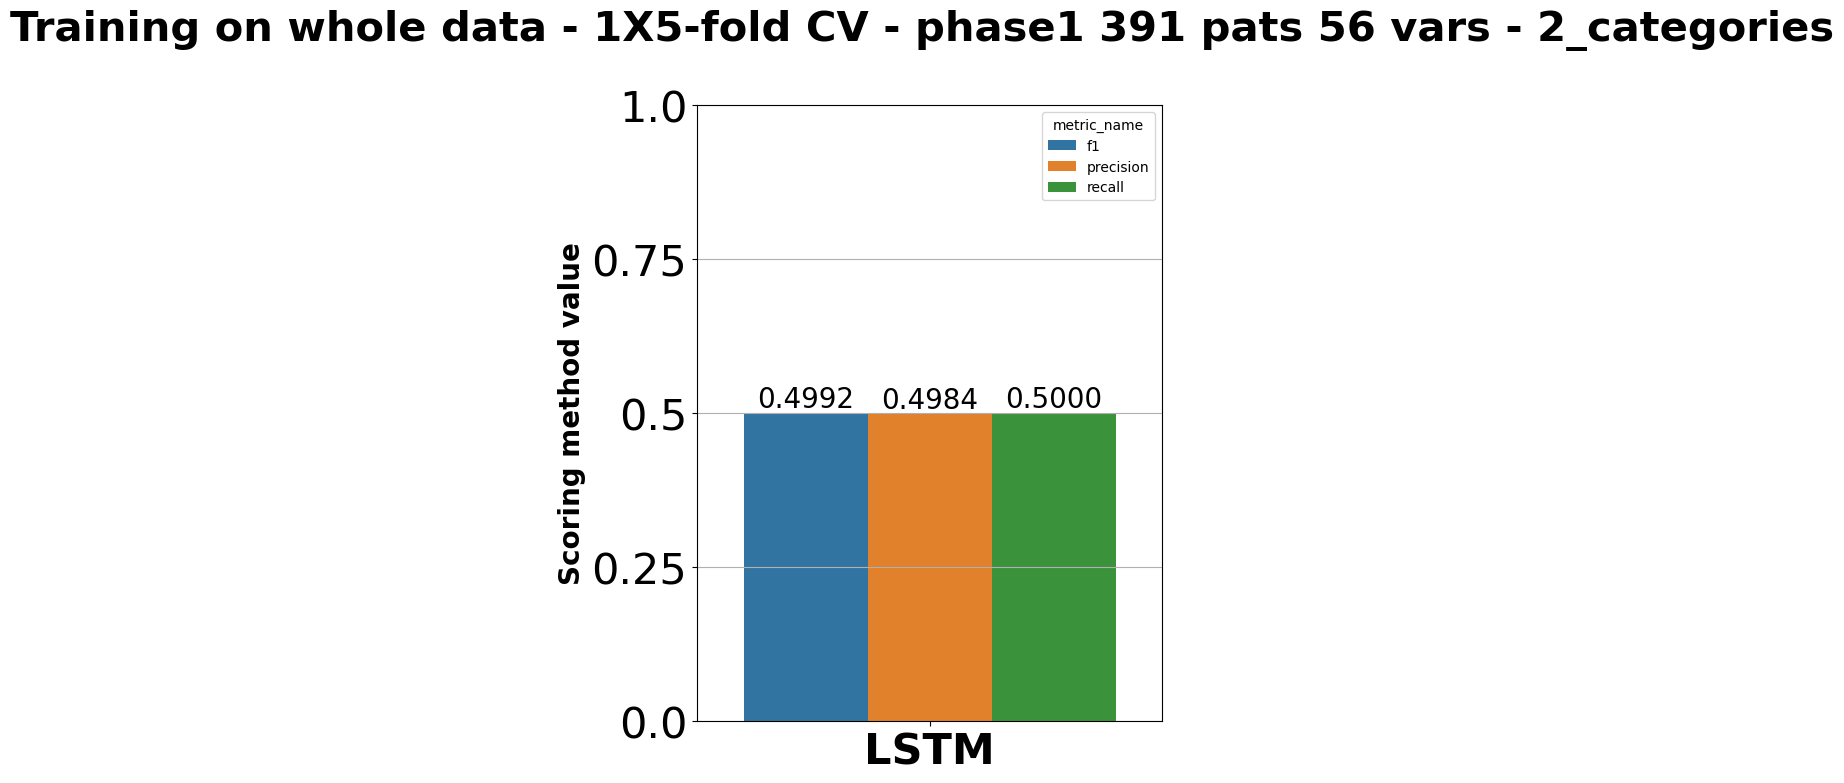

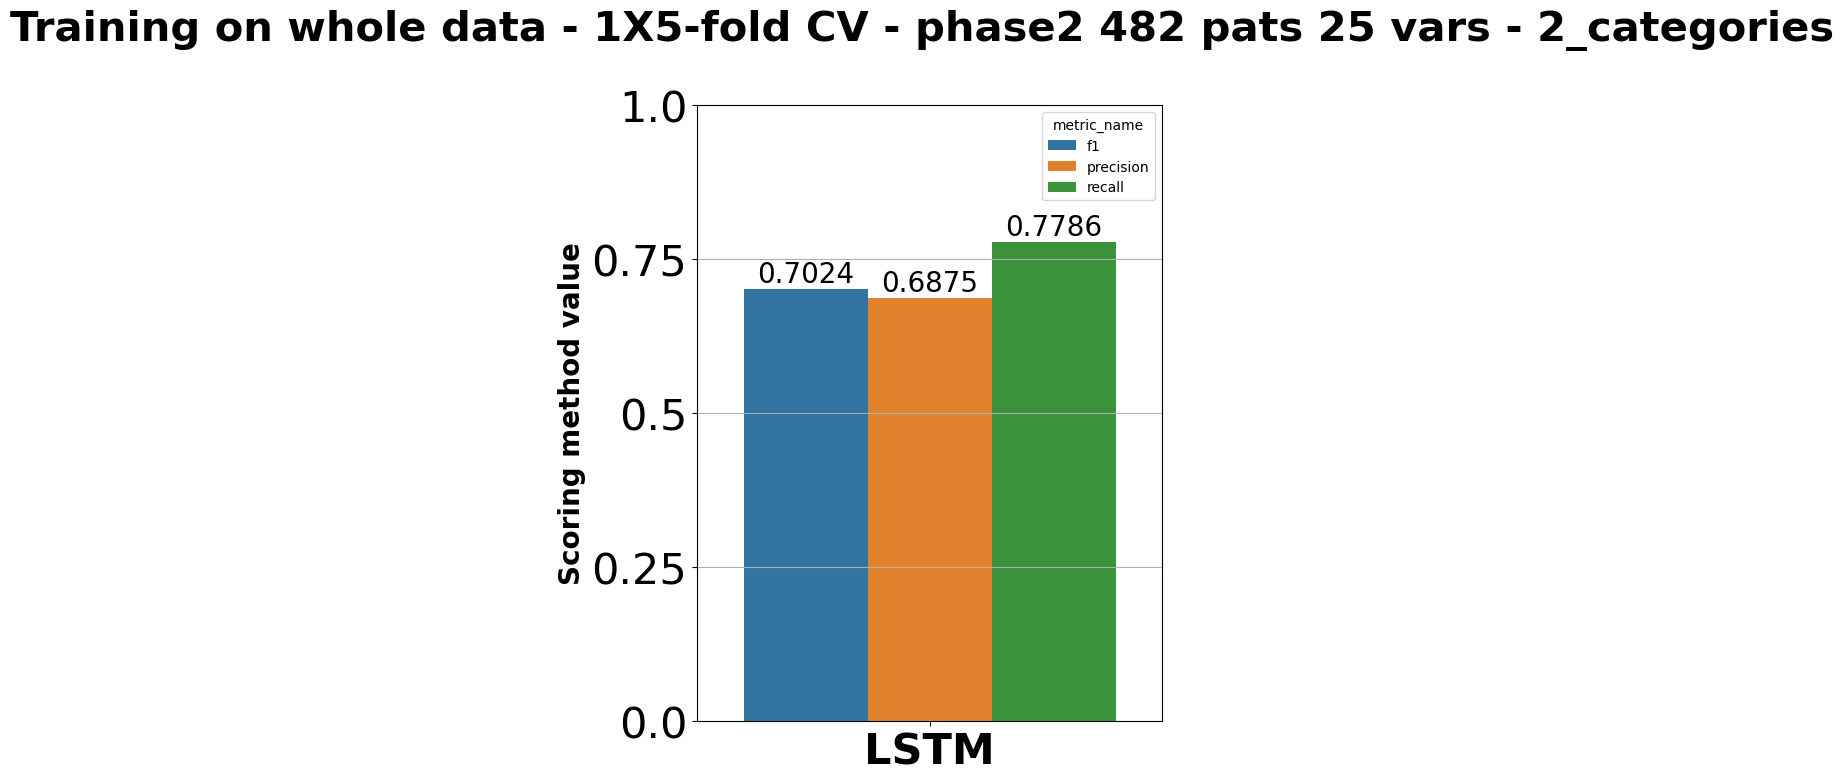

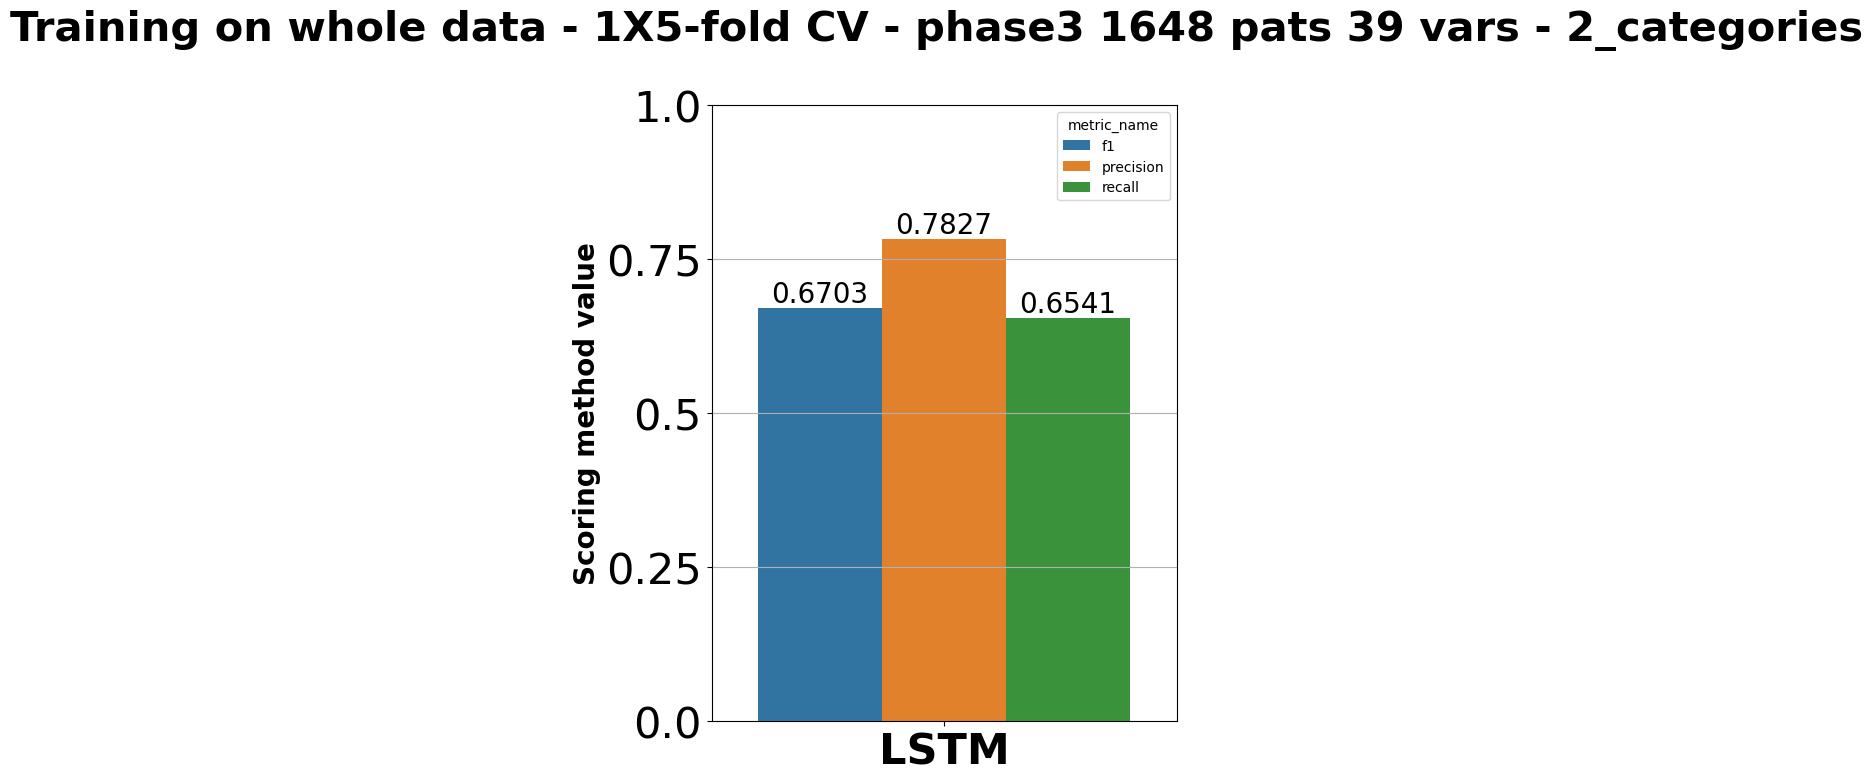

In [58]:
figtitle_size=30
#subtitle_size=20
x_tick_size=31
y_tick_size=31
y_label_size=20
bar_annot_fontsize=20

scoring_methods=['f1','precision','recall']
#model_names=['RandomForest','GradientBoost','XGBoost','DenseNetwork','SVC','KNN','LogisticRegression']#,'Lasso','Ridge']#,'ElasticNet']
model_names=['LSTM']

for ds_name in [*parameters_for_analysis][:3]:
    
    fname='../data/'+ds_name+'_LSTM_class_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)           


    for categorical_map_name in [*categorical_map_dict][:1]:
        test_data_results=result_dict[categorical_map_name]['test_data_results']
        #training_days=result_dict['train_data_results']['training_on_first_x_days']['training_days']
        
        for training_method in training_methods[:1]:
            
            plot_dict={key: value for key, value in test_data_results[training_method].items() \
                        if all(exclude_string not in key for exclude_string in ['_with_index','_X','_model','training_loss_dict'])}
            print(plot_dict.keys())
            pred_df=pd.DataFrame.from_dict(plot_dict)

            fig,axes=plt.subplots(1,1,figsize=(len(model_names)*6,8))
            ax=axes
            plot_df=pd.DataFrame(columns=['model_name','metric_name','metric_value'])
            model_name_list,metric_name_list,metric_value_list=[],[],[]
            for model_name in model_names:
                actual_y=model_name+'_y'
                predicted=model_name+'_predicted'
                print(pred_df[actual_y].value_counts(normalize=False))
                        
                for scoring_method in scoring_methods:
                    scorer=scoring_methods_dict[scoring_method]
                    score_metric_value=scorer(pred_df[actual_y], pred_df[predicted], average='macro')
                    model_name_list.append(model_name)
                    metric_name_list.append(scoring_method)
                    metric_value_list.append(score_metric_value)
                
            plot_df['model_name']=model_name_list
            plot_df['metric_name']=metric_name_list
            plot_df['metric_value']=metric_value_list

            ylim=1.1*(plot_df['metric_value'].max())
            plot_df=plot_df.replace({'RandomForest':'Random\nForest',
                                        'GradientBoost':'Gradient\nBoost',
                                        'LogisticRegression':'Logistic\nRegression',
                                        'DenseNetwork':'Dense\nNetwork',
                                        'ElasticNet':'Elastic\nNet'},regex=True)

            sns.barplot(data=plot_df,x='model_name',y='metric_value',hue='metric_name',ax=ax)
            # Iterate over each bar
            for p in ax.patches:
                # Get the height of the bar
                height = p.get_height()
                
                # Add the y-value on top of the bar
                ax.annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom',fontsize=bar_annot_fontsize)

            ax.set_ylabel('Scoring method value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=x_tick_size,fontweight='bold',rotation=0)
            ax.set_ylim(0,1)
            ax.set_yticks(np.linspace(0,ax.get_ylim()[1],5))
            ax.set_yticklabels(np.round(np.linspace(0,ax.get_ylim()[1],5),2),fontsize=y_tick_size)
            title='TTP values'
            #ax.set_title(title,fontsize=subtitle_size,fontweight='bold')
            ax.grid(axis='y')
            plt.tight_layout

            if training_method=='training_on_first_x_days':
                    suptitle=training_method.replace('x',str(training_days))
                    suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                            
            else:
                suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                        ds_name.replace('_',' ') + ' - '+ categorical_map_name
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1)
            #print(weighted_f1)

'''
        
'''                

### Plot confusion matrices of testing data

dict_keys(['LSTM_y', 'LSTM_y_with_index', 'LSTM_predicted', 'LSTM_x'])
dict_keys(['LSTM_y', 'LSTM_y_with_index', 'LSTM_predicted', 'LSTM_x'])


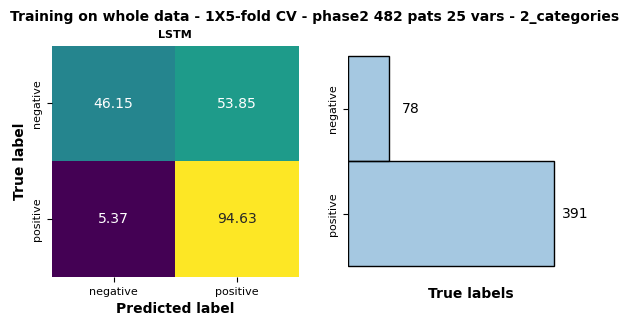

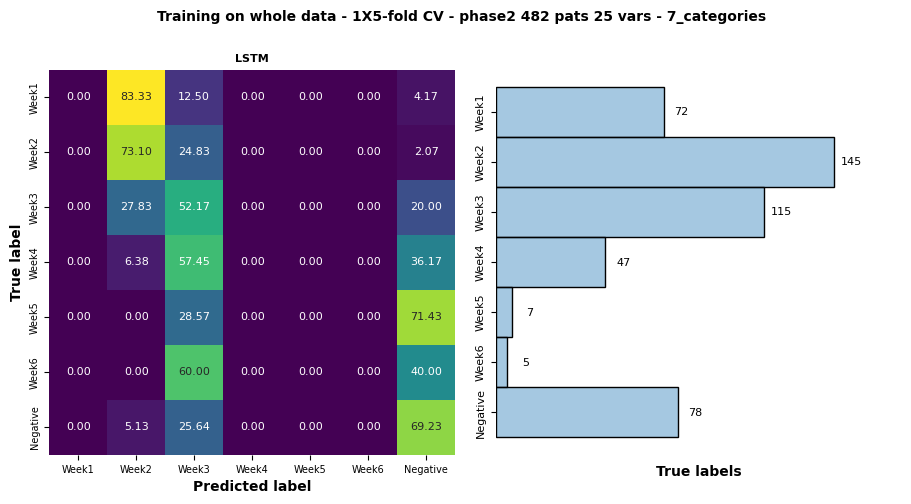

In [125]:
## Set the figtitle sizes  -> the other fontsizes can be found lower in the code 
figtitle_size=10
subtitle_size=8


from sklearn import metrics

model_names=['LSTM']

categorical_map_dict={'2_categories':{'bins':[-1,42,float('inf')],'labels':[1,0],
                                      'labels_str':['positive','negative'],
                                      'weights':[1,1]},
                      '7_categories':{'bins':[-1,1*7,2*7,3*7,4*7,5*7,6*7,float('inf')],'labels':[0,1,2,3,4,5,6],
                                     'labels_str':['Week1','Week2','Week3','Week4','Week5','Week6','Negative'],
                                     'weights':[1,1,1,1,1,1,1]}}

for ds_name in [*parameters_for_analysis][1:2]:
    
    fname='../data/'+ds_name+'_LSTM_class_results.pickle'
    if os.path.exists(fname):
        with open(fname,'rb') as f:
            result_dict=pickle.load(f)           


    for categorical_map_name in [*categorical_map_dict][:]:
        test_data_results=result_dict[categorical_map_name]['test_data_results']
        #training_days=result_dict['train_data_results']['training_on_first_x_days']['training_days']
        
        
        for training_method in training_methods[:1]:
            print(test_data_results[training_method].keys())
            plot_dict={key: value for key, value in test_data_results[training_method].items() \
                        if all(exclude_string not in key for exclude_string in ['_with_index','_x','_model','training_loss_dict'])}
            
            pred_df=pd.DataFrame.from_dict(plot_dict)
            
            if '2' in categorical_map_name:
                row_width_fact=7
                col_height_fact=1.5
                num_col=2
                hspace=0
                wspace=0.2
                y_label_size=10
                bar_annot_fontsize=10
                x_tick_size=8
                y_tick_size=8
                num_row=math.ceil(len(model_names)/num_col)
                fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                fig.subplots_adjust(hspace=hspace,wspace=wspace)

            else:  
                row_width_fact=11
                col_height_fact=2.5
                num_col=2
                hspace=0.2
                wspace=0.1
                y_label_size=10
                bar_annot_fontsize=8
                x_tick_size=7
                y_tick_size=7
                num_row=math.ceil(len(model_names)/num_col)
                fig=plt.figure(figsize=(len(model_names)*row_width_fact,num_col*col_height_fact))
                fig.subplots_adjust(hspace=hspace,wspace=wspace)
                #plt.tight_layout() 
            
            

            #fig,axes=plt.subplots(num_col,math.ceil(len(model_names)/num_col),figsize=(len(model_names)*5,6))
            #for ax,model_name in zip(axes.flatten(),model_names):

            for n,model_name in enumerate(model_names):
                actual_y=model_name+'_y'
                predicted=model_name+'_predicted'

                confusion_matrix=pd.crosstab(pred_df[actual_y], pred_df[predicted], 
                                               rownames=['Actual'], colnames=['Predicted'],margins=True)
                
                ## Convert to dataframe and rename columns to label strings from numbers
                confusion_matrix_=metrics.confusion_matrix(pred_df[actual_y], pred_df[predicted],normalize='true')
                confusion_matrix_=pd.DataFrame(confusion_matrix_)
                label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                    categorical_map_dict[categorical_map_name]['labels_str']))

                confusion_matrix_=confusion_matrix_.rename(columns=label_dict)
                confusion_matrix_=confusion_matrix_.rename(index=label_dict)

                ax=fig.add_subplot(num_row,num_col,n+1)
                sns.heatmap(confusion_matrix_*100,ax=ax,annot=True,cbar=False, cmap='viridis', fmt='.2f',
                            annot_kws={"size":bar_annot_fontsize})
                
                ax.set_title(model_name,fontsize=subtitle_size,fontweight='bold')
                ax.set_ylabel('True label',fontsize=y_label_size,fontweight='bold')
                ax.set_xlabel('Predicted label',fontsize=y_label_size,fontweight='bold')
                ax.set_xticklabels(ax.get_xticklabels(), fontsize=x_tick_size)
                ax.set_yticklabels(ax.get_yticklabels(), fontsize=y_tick_size)

            ## Add th distri ution of the predicted variable as last subplot
            ax=fig.add_subplot(num_row,num_col,n+2)
            categorical_map_name_key=list(set(['LSTM_y_with_index' for key in \
                                        test_data_results[training_method].keys() if '_y_with_index' in key]))[0] 
            
            plot_df=test_data_results[training_method][categorical_map_name_key]
            plot_df=plot_df.reset_index()
            #plot_df=plot_df.rename(columns=color_by_legend_title)

            label_dict=dict(zip(categorical_map_dict[categorical_map_name]['labels'],
                                    categorical_map_dict[categorical_map_name]['labels_str']))

            plot_df['mb_Time to Detection_RESULT']=plot_df['mb_Time to Detection_RESULT'].replace(label_dict,regex=True)
            if '2' in categorical_map_name:
                plot_df['mb_Time to Detection_RESULT']=pd.Categorical(plot_df['mb_Time to Detection_RESULT'],['negative','positive'])
                bar_offset_fact=0.1
            else:
                bar_offset_fact=0.05  
            histp=sns.histplot(data=plot_df,y='mb_Time to Detection_RESULT',ax=ax,#hue=color_by_legend_title[color_by],
                         alpha=0.4,kde=False,linewidth=None)

            
            # Add count annotations next to the bars
            for p in histp.patches:
                histp.annotate(f'{int(p.get_width())}', (p.get_width()+ax.get_xlim()[1]*bar_offset_fact, p.get_y()+p.get_height() / 2), 
                                ha='center', va='center',fontsize=bar_annot_fontsize)

            # Remove x-label ticks on the x-axis
            ax.set_xticks([])                       
            ax.set_xlim(0,int(round(plot_df['mb_Time to Detection_RESULT'].value_counts().max()*1.2)))
            ax.set_xlabel('True labels',fontsize=y_label_size,fontweight='bold')
            #ax.set_ylabel('Count',fontsize=ylabel_size,fontweight='bold')
            # Remove y-axis ticks and labels

            # Set y-axis tick positions and labels
            ax.set_ylabel('') 
            ax.tick_params(axis='y', labelsize=y_label_size*0.8)
            
            for label in ax.get_yticklabels():
                label.set_rotation(90)
                label.set_va('center')
            #ax.set_title('Label distribution',fontsize=y_label_size,fontweight='bold')
            
            # Remove the frame (border) around the plot
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)

            if training_method=='training_on_first_x_days':
                    suptitle=training_method.replace('x',str(training_days))
                    suptitle=suptitle.replace('_',' ').capitalize() + ' - '+ str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                            ds_name.replace('_',' ') + ' - '+ categorical_map_name
                            
            else:
                suptitle=training_method.replace('_',' ').capitalize()+' - '+str(num_of_cv_repeats)+'X'+ str(k_folds)+'-fold CV - '+\
                        ds_name.replace('_',' ') + ' - '+ categorical_map_name
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1) 